# ISH-LITE and UFS-CHEM

Our first example will demonstrate the basics available in MELODIES MONET to 
compare UFS-CHEM results against ISH-LITE surface observations for temperature, wind speed, and dewpoint.

ISH is a particularly useful for model evaluations because it is a global dataset. As you will see in the YAML file, we can create plots globally, for individual countries, and states. NOTE: MELODIES-MONET examples that use ISH will take longer to finish running due to the larger amount of data.

First, we import the {mod}`melodies_monet.driver` module.

In [1]:
from melodies_monet import driver

## Analysis driver class

Now, lets create an instance of the analysis driver class, {class}`melodies_monet.driver.analysis`.
It consists of these main parts:
* model instances
* observation instances
* a paired instance of both

In [2]:
an = driver.analysis()

Initially, most of our {class}`~melodies_monet.driver.analysis` object's attributes
are set to ``None``, though some have meaningful defaults:

In [3]:
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control file

We set the YAML control file and begin by reading the file.

```{note}
Check out the {doc}`/appendix/yaml` for info on how to create
and modify these files.
```

In [4]:
an.control = "control_ish_lite_ufschem-example.yaml"
an.read_control()
an.control_dict

{'analysis': {'start_time': '2017-07-01-00:00:00',
  'end_time': '2017-07-03-00:00:00',
  'output_dir': './output/ish_lite_ufschem',
  'debug': True},
 'model': {'ufschem_v1': {'files': 'example:ufschem:2017-07',
   'files_surf': 'example:ufschem:2017-07_sfc',
   'mod_type': 'ufs',
   'is_global': True,
   'mod_kwargs': {'surf_only': True,
    'sfc_varlist': ['tmp2m', 'spfh2m', 'ugrd10m', 'vgrd10m']},
   'radius_of_influence': 100000,
   'extra_calc': {'dewpoint': {'pres_calc': 'surfpres_pa',
     'specific_hum': 'spfh2m'},
    'rel_hum': {'pres_calc': 'surfpres_pa',
     'specific_hum': 'spfh2m',
     'temp_calc': 'tmp2m'},
    'windspeed': {'u_comp': 'ugrd10m', 'v_comp': 'vgrd10m'},
    'winddir': {'u_comp': 'ugrd10m', 'v_comp': 'vgrd10m'},
    'wind_barb': {'u_comp': 'ugrd10m', 'v_comp': 'vgrd10m'},
    'rose_plot': {'model_wdir': 'winddir', 'model_wspd': 'windspeed'}},
   'mapping': {'ish_lite': {'tmp2m': 'temp',
     'windspeed': 'ws',
     'dewpoint': 'dew_pt_temp'}},
   'project

````{admonition} Note: This is the complete file that was loaded.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
```
````

Now, some of our {class}`~melodies_monet.driver.analysis` object's attributes are populated:

In [5]:
an

analysis(
    control='control_ish_lite_ufschem-example.yaml',
    control_dict=...,
    models={},
    obs={},
    paired={},
    start_time=Timestamp('2017-07-01 00:00:00'),
    end_time=Timestamp('2017-07-03 00:00:00'),
    time_intervals=None,
    download_maps=True,
    output_dir='./output/ish_lite_ufschem',
    output_dir_save='./output/ish_lite_ufschem',
    output_dir_read='./output/ish_lite_ufschem',
    debug=True,
    save=None,
    read=None,
    regrid=False,
)

## Load the model data

The driver will automatically loop through the "models" found in the `model` section
of the YAML file and create an instance of {class}`melodies_monet.driver.model` for each
that includes the
* label
* mapping information
* file names (can be expressed using a glob expression)
* xarray object

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 24-56
```
````

In [6]:
an.open_models()

ufs
example:ufschem:2017-07
**** Reading UFS-AQM or UFS-Chem model output...
Performing extra model calculations...
Calculating modeled Dewpoint...
Calculating modeled relative humidity...
Calculating modeled windpseed...
Calculating modeled wind direction...
No extra calculations performed.


Applying {meth}`~melodies_monet.driver.analysis.open_models`
populates the {attr}`~melodies_monet.driver.analysis.models` attribute.

In [7]:
an.models

{'ufschem_v1': model(
     model='ufs',
     is_global=True,
     radius_of_influence=100000,
     mod_kwargs={'surf_only': True, 'sfc_varlist': ['tmp2m', 'spfh2m', 'ugrd10m', 'vgrd10m'], 'fname_sfc': ['/home/rschwantes/.cache/pooch/5207e0e702072b5e37fd507da111f78d-2017_07_01_03_ufschemv1_sfc.nc'], 'var_list': ['lat', 'lon', 'phalf', 'tmp', 'pressfc', 'dpres', 'hgtsfc', 'delz']},
     file_str='example:ufschem:2017-07',
     label='ufschem_v1',
     obj=...,
     extra_calc={'dewpoint': {'pres_calc': 'surfpres_pa', 'specific_hum': 'spfh2m'}, 'rel_hum': {'pres_calc': 'surfpres_pa', 'specific_hum': 'spfh2m', 'temp_calc': 'tmp2m'}, 'windspeed': {'u_comp': 'ugrd10m', 'v_comp': 'vgrd10m'}, 'winddir': {'u_comp': 'ugrd10m', 'v_comp': 'vgrd10m'}, 'wind_barb': {'u_comp': 'ugrd10m', 'v_comp': 'vgrd10m'}, 'rose_plot': {'model_wdir': 'winddir', 'model_wspd': 'windspeed'}},
     mapping={'ish_lite': {'tmp2m': 'temp', 'windspeed': 'ws', 'dewpoint': 'dew_pt_temp'}},
     variable_dict={'surfpres_pa':

We can access the underlying dataset with the
{attr}`~melodies_monet.driver.model.obj` attribute.

In [8]:
an.models['ufschem_v1'].obj

<xarray.Dataset> Size: 320MB
Dimensions:        (y: 192, x: 384, time: 72, z: 1)
Coordinates:
    latitude       (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    longitude      (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
  * time           (time) datetime64[ns] 576B 2017-07-01T01:00:00 ... 2017-07-04
  * x              (x) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * y              (y) float64 2kB 89.28 88.36 87.42 ... -87.42 -88.36 -89.28
Dimensions without coordinates: z
Data variables: (12/14)
    temperature_k  (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    surfpres_pa    (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    dp_pa          (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    surfalt_m      (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    dz_m           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    pres_pa_mid    (time, z, y, x) float64 42MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ...             ...
    ugrd10m        (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    vgrd10m        (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    dewpoint       (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    rel_hum        (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    windspeed      (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    winddir        (time, z, y, x) float32 21MB 243.3 244.2 ... 352.7 351.9
Attributes:
    grid:         gaussian
    grid_id:      1
    hydrostatic:  non-hydrostatic
    im:           384
    jm:           192
    ncnsto:       139
    source:       FV3GFS
    NCO:          netCDF Operators version 5.0.7 (Homepage = http://nco.sf.ne...
    ak:           [0. 0.]
    bk:           [0.99467119 1.        ]
    history:      Fri Feb 27 09:53:22 2026: ncrcat 20170701_dynf001.nc 201707...

## Load the observational data

As with the model data, the driver will loop through the "observations" found in
the `obs` section of the YAML file and create an instance of
{class}`melodies_monet.driver.observation` for each.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 58-99
```
````

In [9]:
an.open_obs()

Performing extra calculations for obs...
No extra calculations performed.


In [10]:
an.obs

{'ish_lite': observation(
     obs='ish_lite',
     label='ish_lite',
     file='example:ish-lite:2017-07',
     obj=...,
     extra_calc={'rose_plot': {'obs_wdir': 'wdir', 'obs_wspd': 'ws'}},
     type='pt_src',
     sat_type=None,
     sat_method=None,
     data_proc=None,
     variable_dict={'temp': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Temperature 2m (K)', 'xlabel_plot': 'Temperature 2m (K)', 'vmin_plot': 273.15, 'vmax_plot': 313, 'vdiff_plot': 20.0, 'nlevels_plot': 21}, 'ws': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Windspeed 10m (m/s)', 'xlabel_plot': 'Windspeed 10m (m/s)', 'vmin_plot': 0, 'vmax_plot': 15, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'wdir': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Wind Direction 10m (deg)', 'xlabel_plot': 'Wind Direction 10m (deg)', 'vmin_plot': 0, 'vmax_plot': 370, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'dew_pt_temp': {'unit_scale':

In [11]:
an.obs['ish_lite']

observation(
    obs='ish_lite',
    label='ish_lite',
    file='example:ish-lite:2017-07',
    obj=...,
    extra_calc={'rose_plot': {'obs_wdir': 'wdir', 'obs_wspd': 'ws'}},
    type='pt_src',
    sat_type=None,
    sat_method=None,
    data_proc=None,
    variable_dict={'temp': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Temperature 2m (K)', 'xlabel_plot': 'Temperature 2m (K)', 'vmin_plot': 273.15, 'vmax_plot': 313, 'vdiff_plot': 20.0, 'nlevels_plot': 21}, 'ws': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Windspeed 10m (m/s)', 'xlabel_plot': 'Windspeed 10m (m/s)', 'vmin_plot': 0, 'vmax_plot': 15, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'wdir': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Wind Direction 10m (deg)', 'xlabel_plot': 'Wind Direction 10m (deg)', 'vmin_plot': 0, 'vmax_plot': 370, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'dew_pt_temp': {'unit_scale': 273.15, 'unit_scale_me

## Pair model and observational data

Now, we create a {class}`melodies_monet.driver.pair` for each model--obs pair
using the {meth}`~melodies_monet.driver.analysis.pair_data` routine.

In [12]:
%%time

an.pair_data()

1, in pair data
After pairing:               time    temp  dew_pt_temp   press   wdir   ws  sky_condition  \
0      2017-07-01     NaN          NaN     NaN    NaN  NaN            9.0   
1      2017-07-01     NaN          NaN     NaN    NaN  NaN            NaN   
2      2017-07-01  271.95       271.75  1019.5  320.0  4.0            NaN   
3      2017-07-01  275.15       272.95  1018.2   80.0  2.0            2.0   
4      2017-07-01  274.25       271.05  1019.6  330.0  2.0            NaN   
...           ...     ...          ...     ...    ...  ...            ...   
598334 2017-07-03  298.15       290.05     NaN  360.0  3.6            NaN   
598335 2017-07-03  295.85       284.55     NaN    0.0  0.0            NaN   
598336 2017-07-03  293.35       287.75     NaN  280.0  3.1            NaN   
598337 2017-07-03  301.55       295.45     NaN  340.0  1.5            NaN   
598338 2017-07-03  301.15       296.15     NaN   90.0  1.5            NaN   

        precip_1hr  precip_6hr       siteid

In [13]:
an.paired

{'ish_lite_ufschem_v1': pair(
     type='pt_sfc',
     radius_of_influence=1000000.0,
     obs='ish_lite',
     model='ufschem_v1',
     model_vars=['tmp2m', 'windspeed', 'dewpoint'],
     obs_vars=['temp', 'ws', 'dew_pt_temp'],
     filename='ish_lite_ufschem_v1.nc',
 )}

In [14]:
an.paired['ish_lite_ufschem_v1']

pair(
    type='pt_sfc',
    radius_of_influence=1000000.0,
    obs='ish_lite',
    model='ufschem_v1',
    model_vars=['tmp2m', 'windspeed', 'dewpoint'],
    obs_vars=['temp', 'ws', 'dew_pt_temp'],
    filename='ish_lite_ufschem_v1.nc',
)

## MELODIES-MONET now contains several meteorological capabilities 

In addition to previous capabilites and plots, users can now:

* Specify wind barbs
    * Note: users may experience longer wait times if they wish to plot wind barbs
* Create rose plots for pollution and wind speed
    * Rose plots can be aggregated at the CONUS-, EPA region-, and MSA-scale 
* Create boxplots on given intervals for any of the supported meteorological variables 
* Mark statistical significance on boxplots


## Plot

The {meth}`~melodies_monet.driver.analysis.plotting` routine produces plots.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 101-240
```
````

**NOTE:** That ISH-lite data for calm wind sets windspeed = 0 and wind direction = 0. In the wind-rose plots, calm winds are plotted as an inner circle for wind direction and data is removed for pollution rose plots based on the threshold set in your yaml file. 

All other plots, it's up to the user on what to consider for these calm winds. Plots below and corresponding yaml file demonstrates how to remove all calm winds from the calculation for the timeseries plots (second set of plots plot_grp1a) and the spatial overlay plots (second set of plots plot_grp3a). You can see that windspeed biases go down when removing these calm winds. Additional processing and consideration for calm winds is under development.

Reference std: 4.161763427919396
Reference std: 2.1283981253197726
Reference std: 2.59924379404348
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ish_lite vs. ufschem_v1: Custom statistical test, P_val:6.102e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ish_lite vs. ufschem_v1: Custom statistical test, P_val:3.069e-205
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ish_lite vs. ufschem_v1: Custom statistical test, P_val:1.517e-19
Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/ish_lite_ufschem/plot_gr

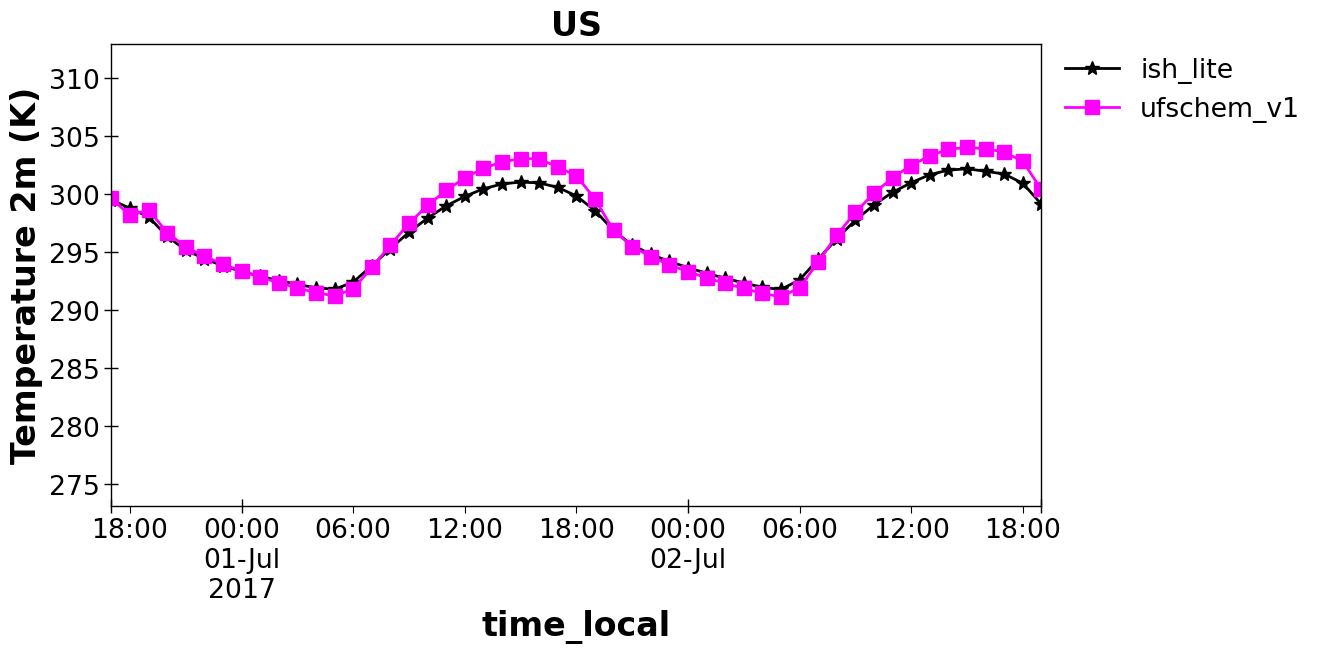

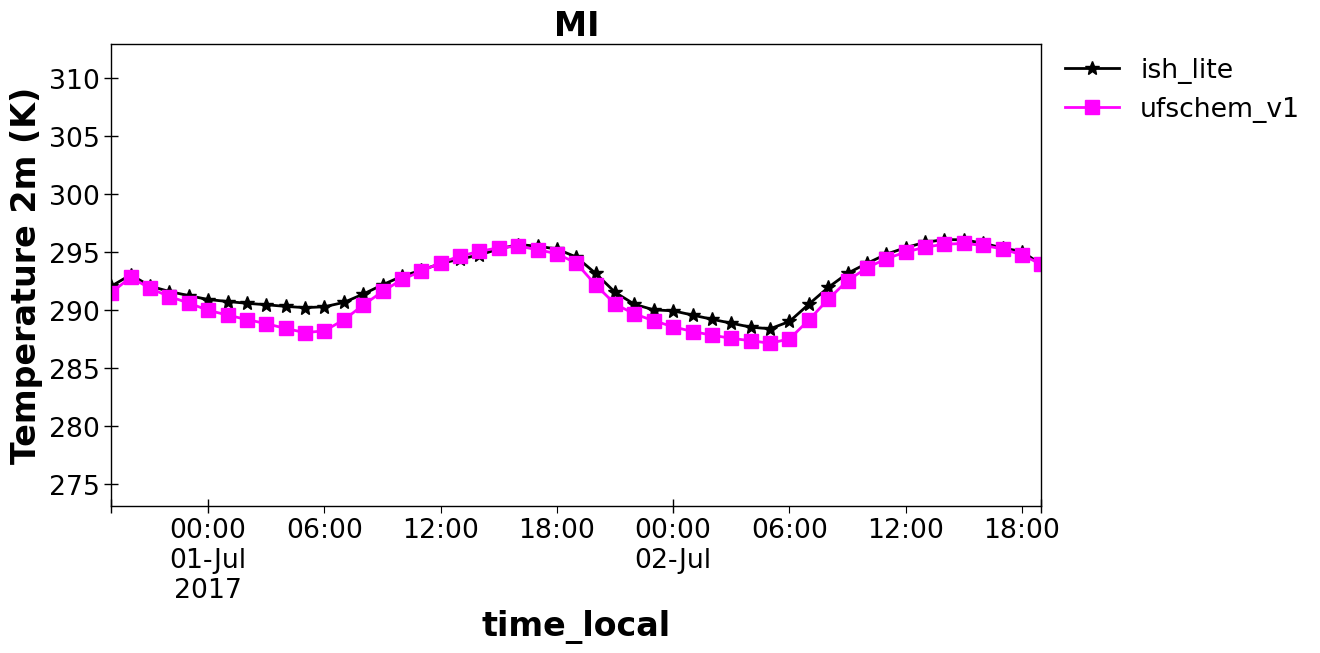

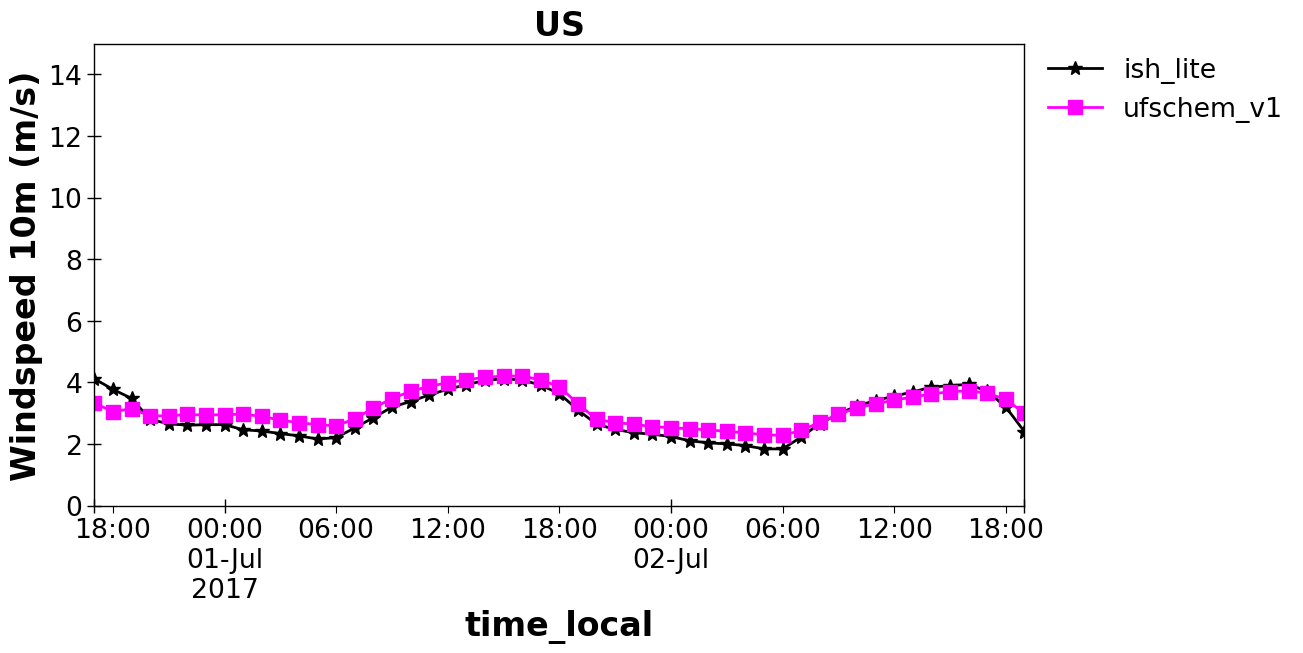

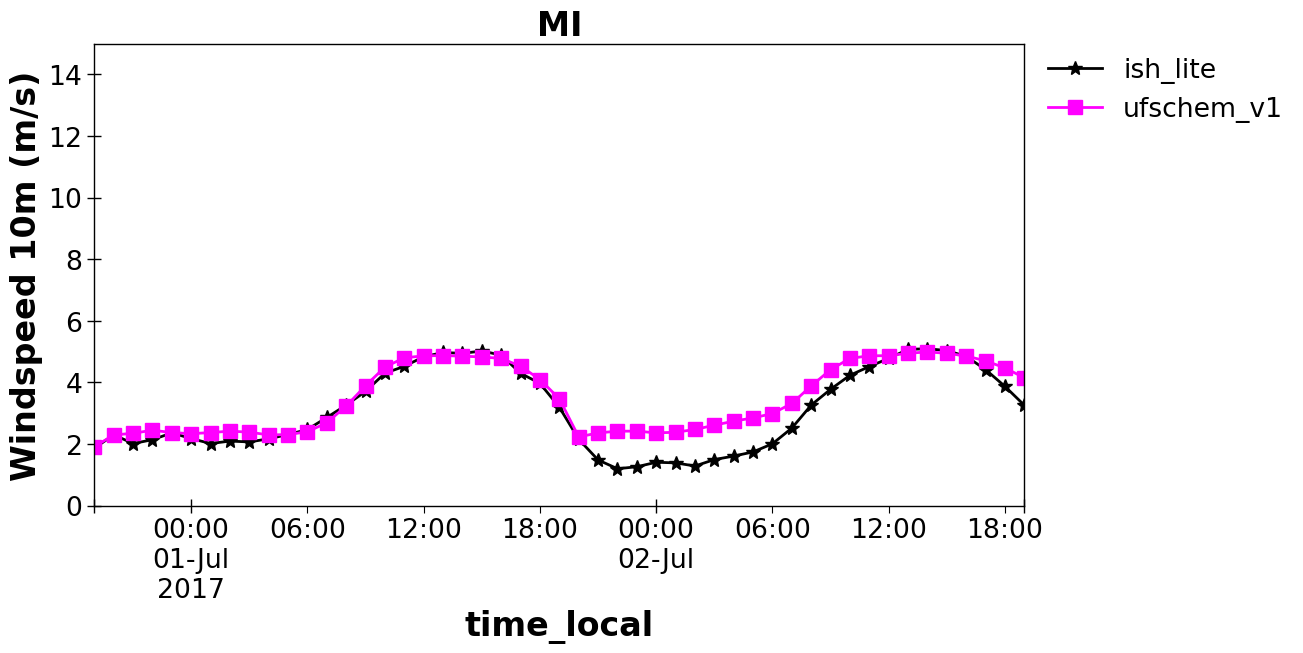

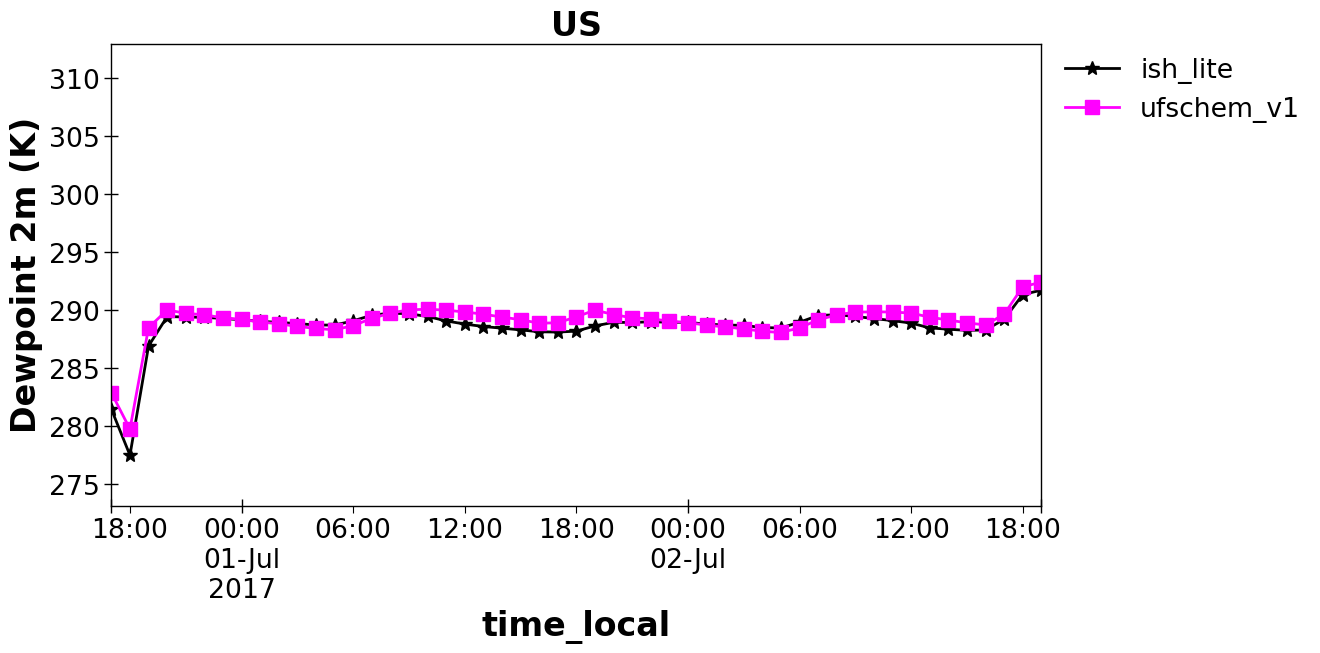

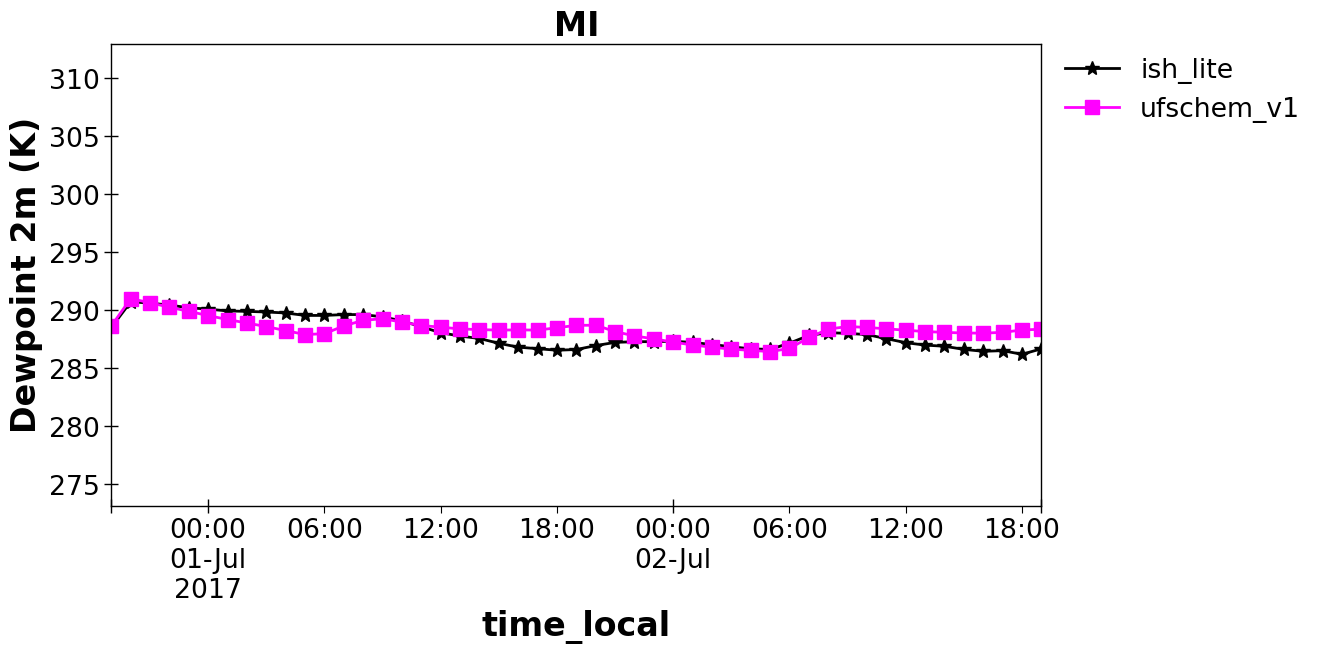

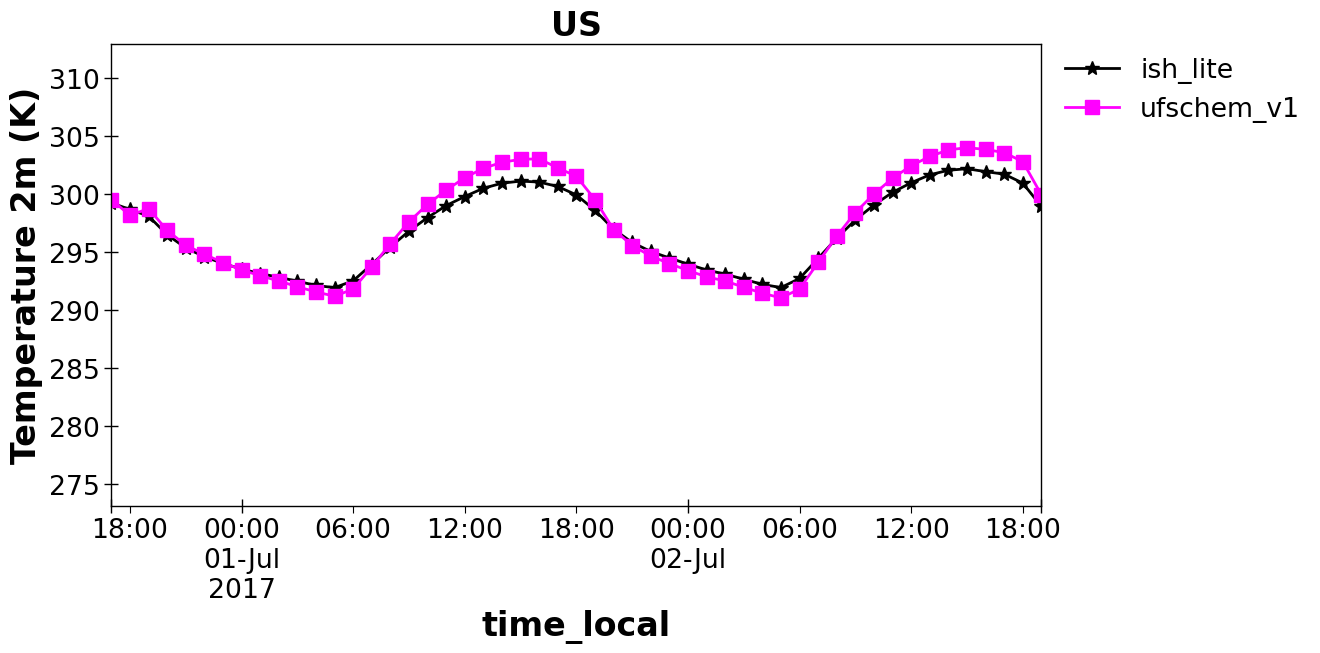

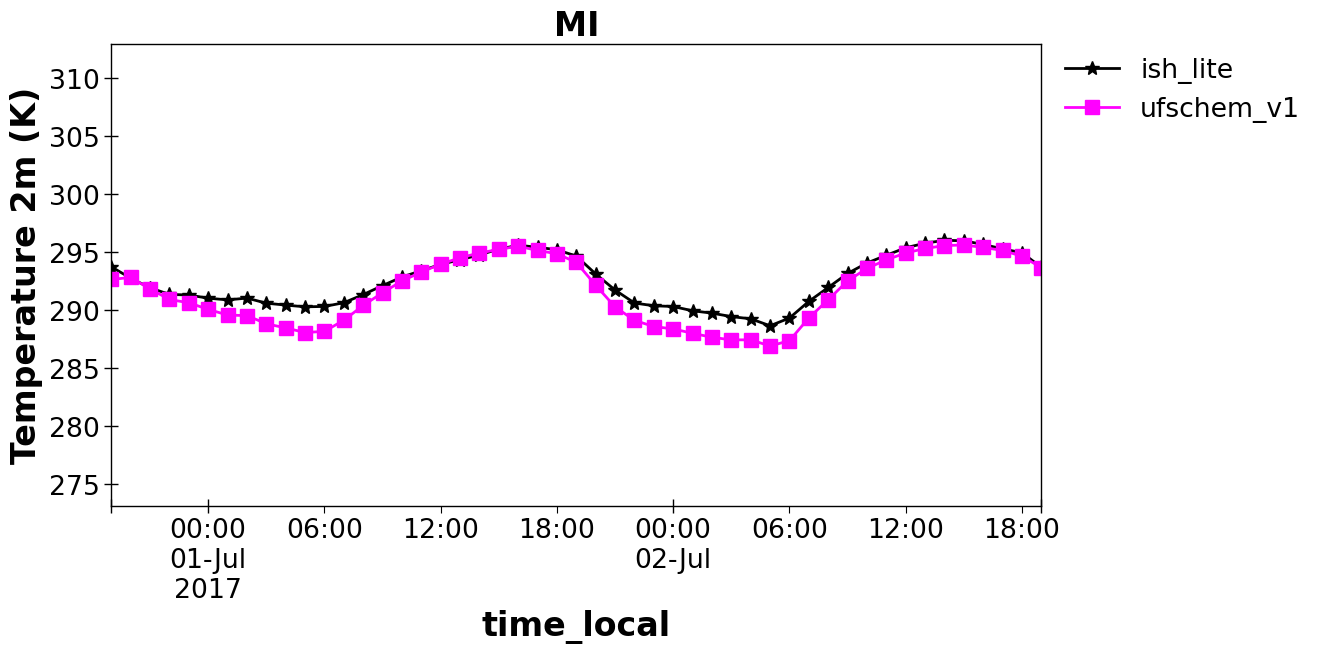

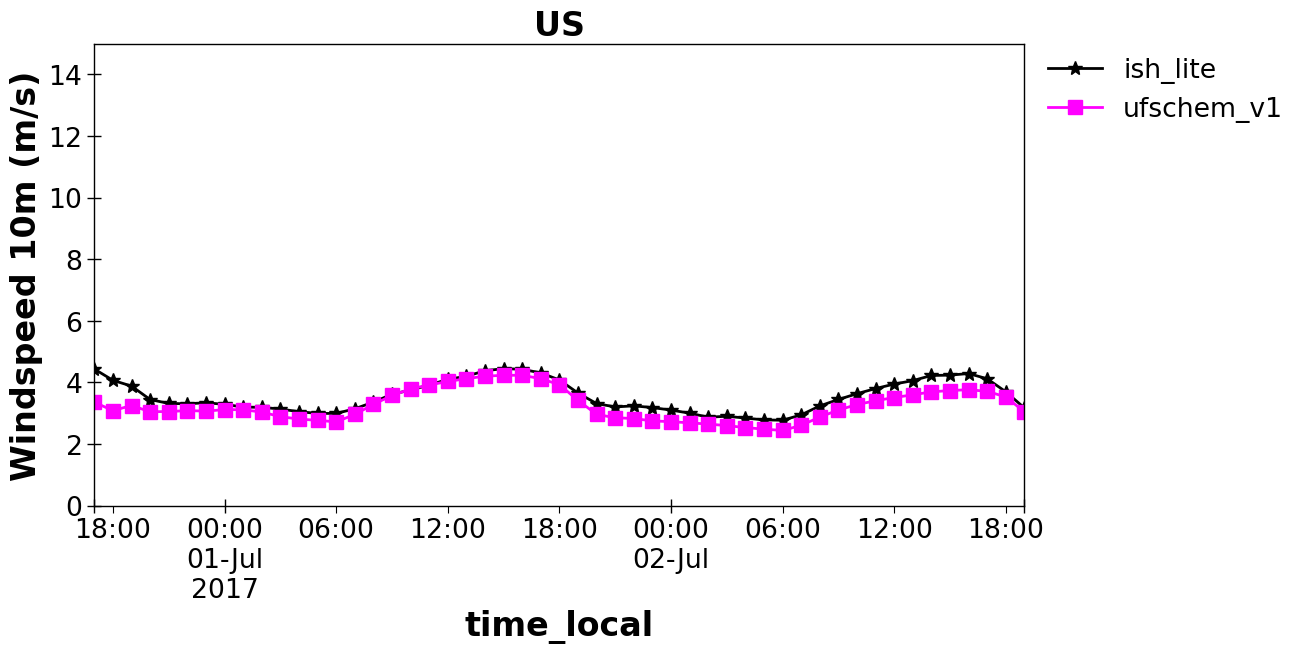

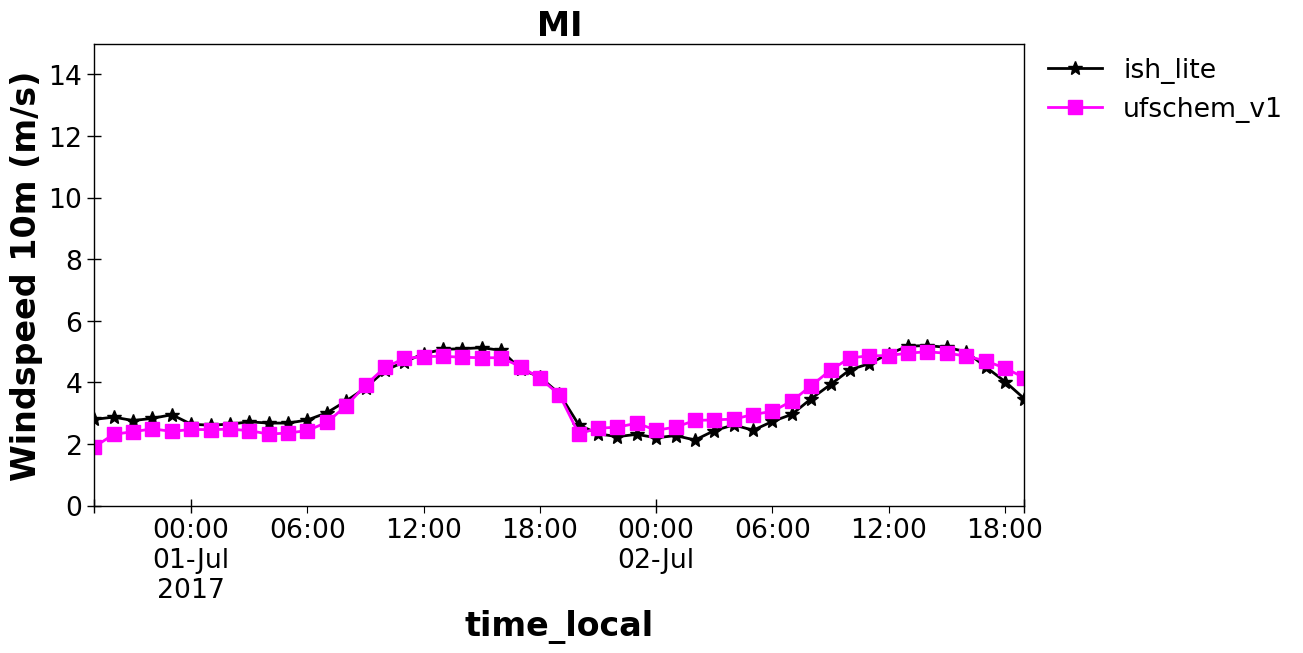

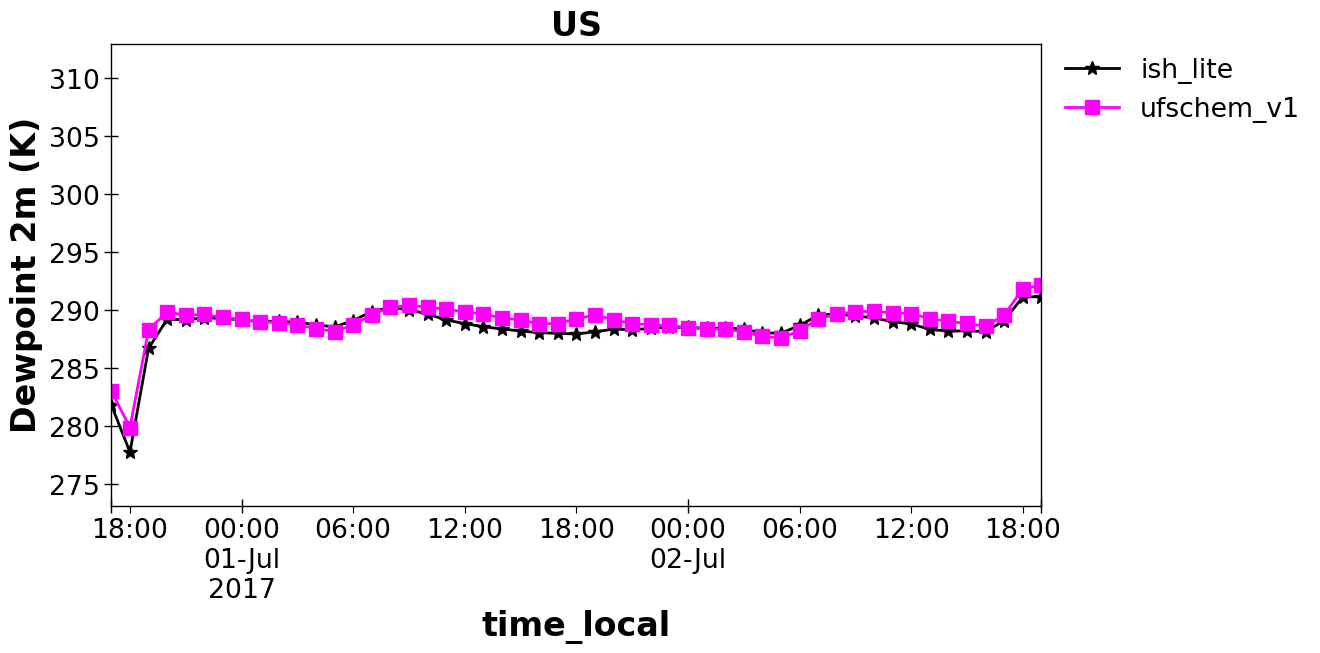

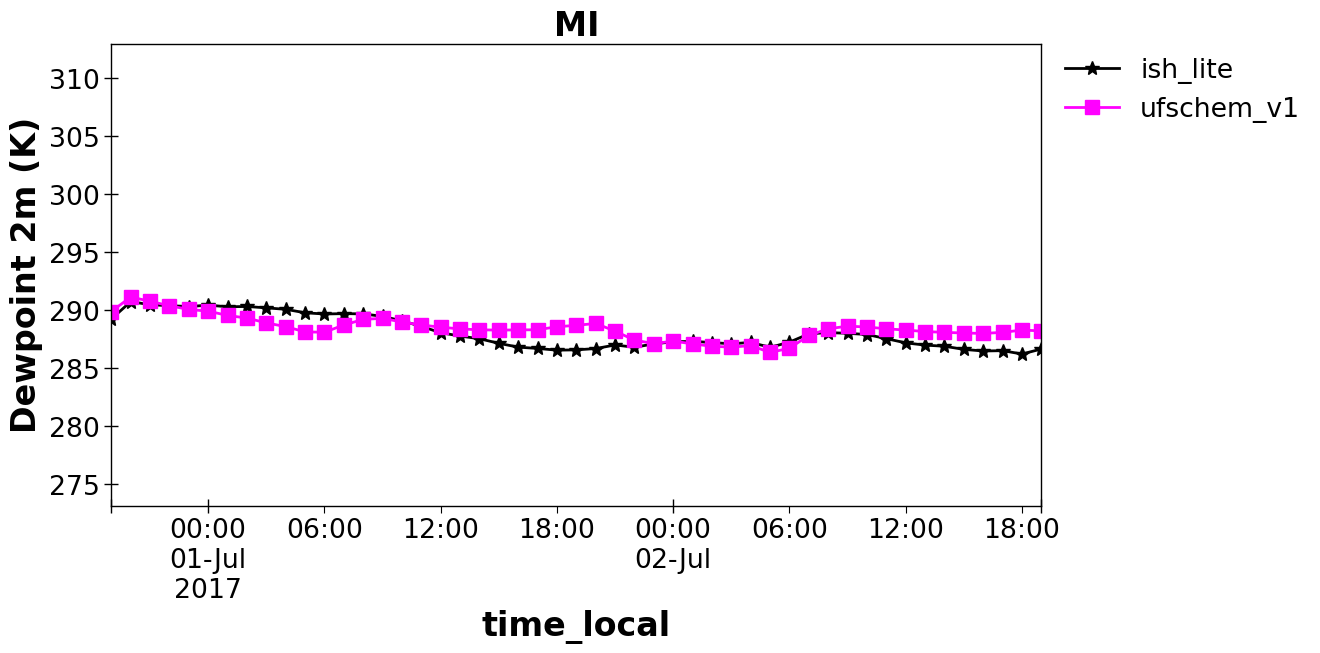

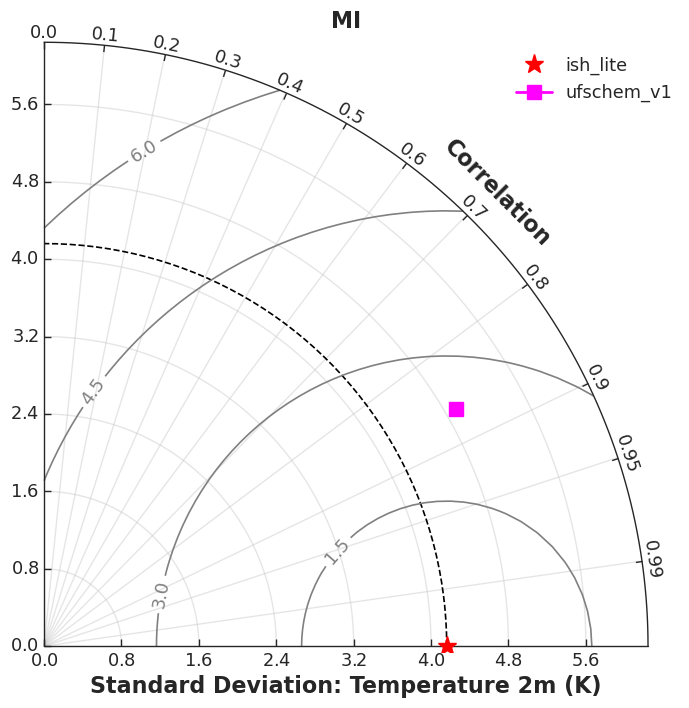

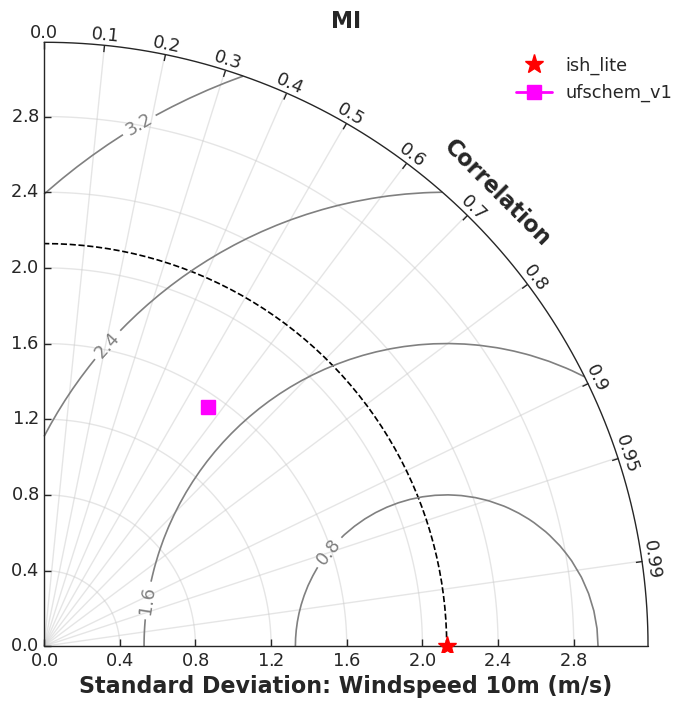

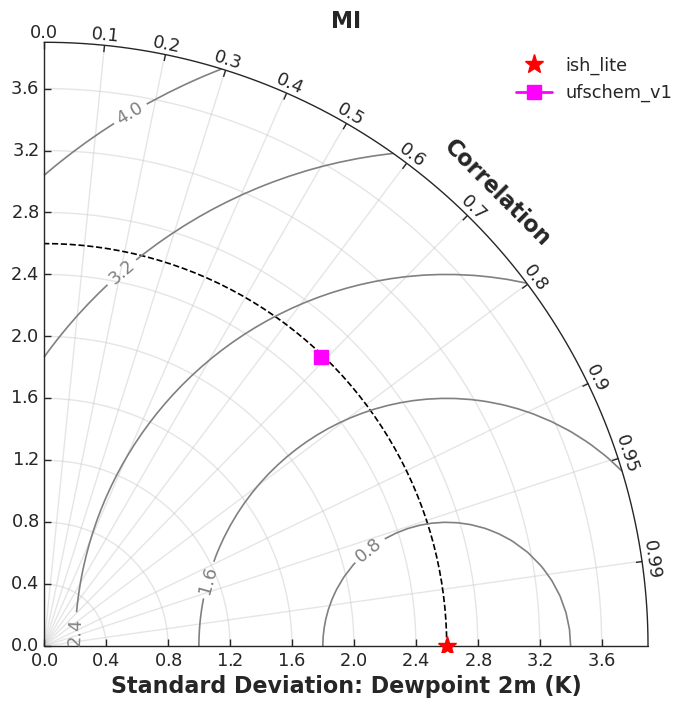

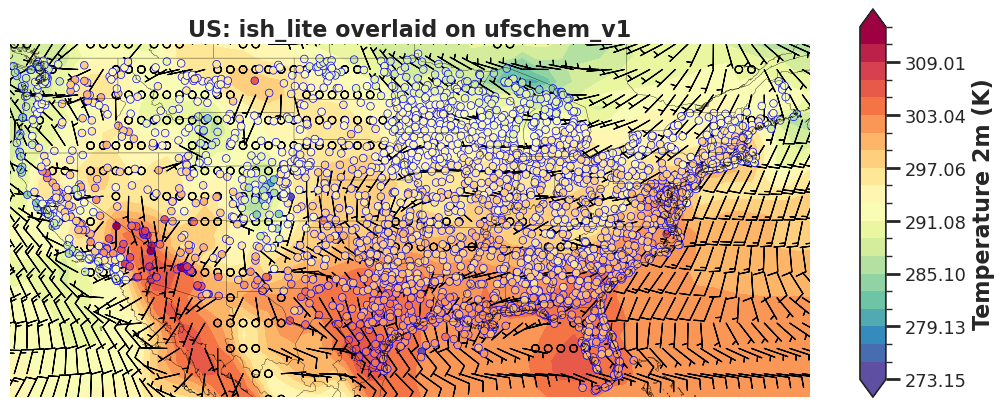

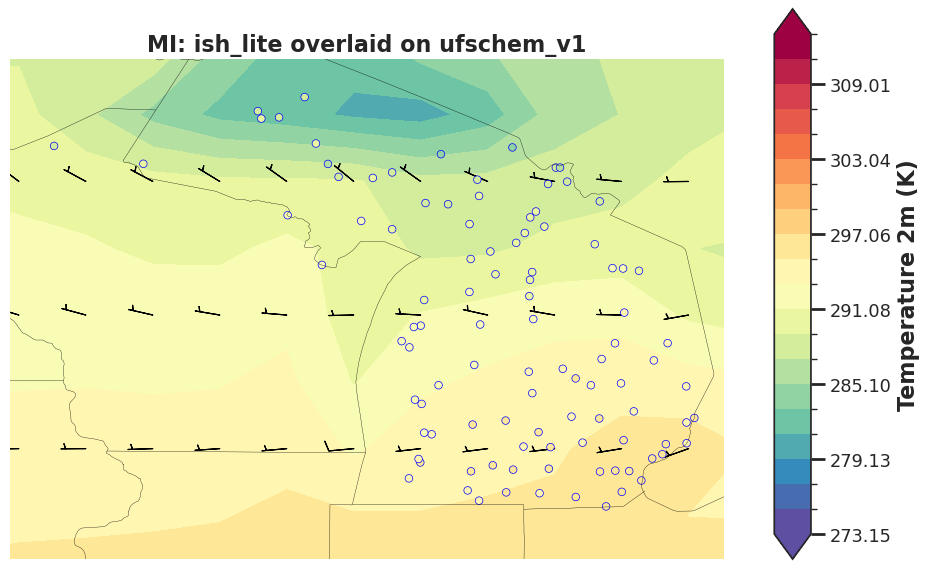

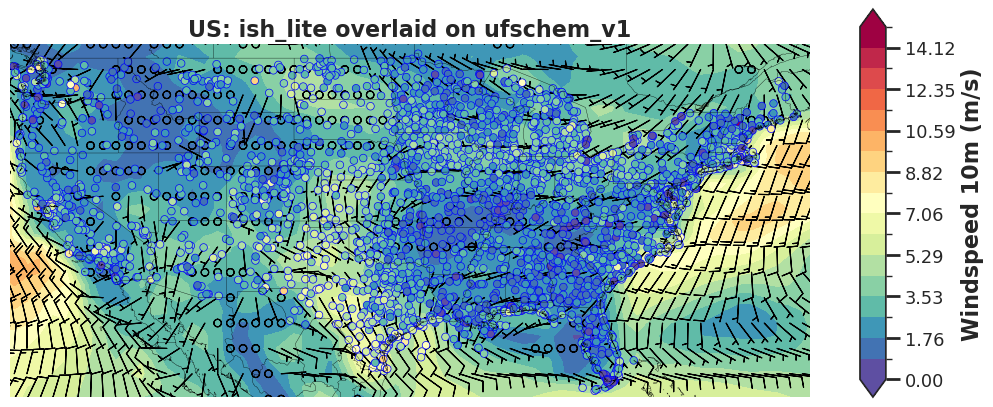

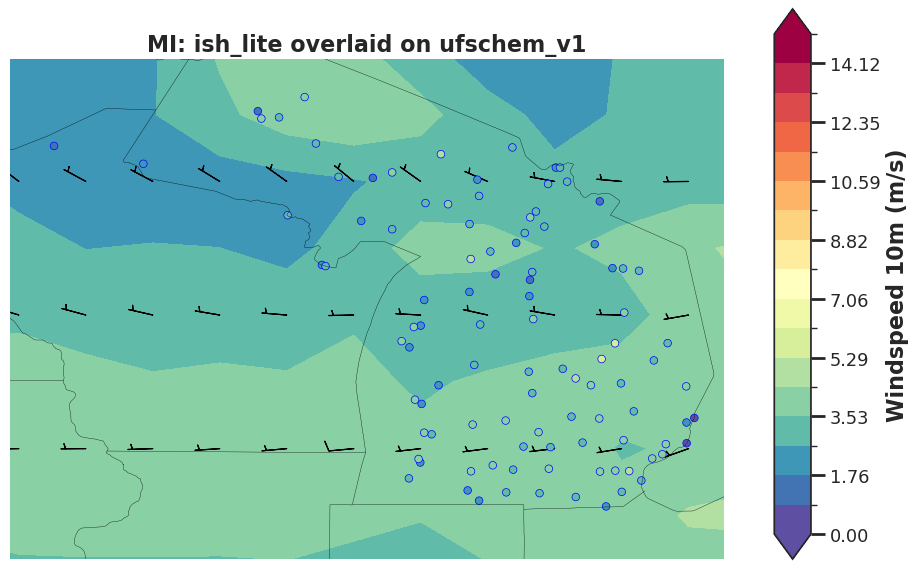

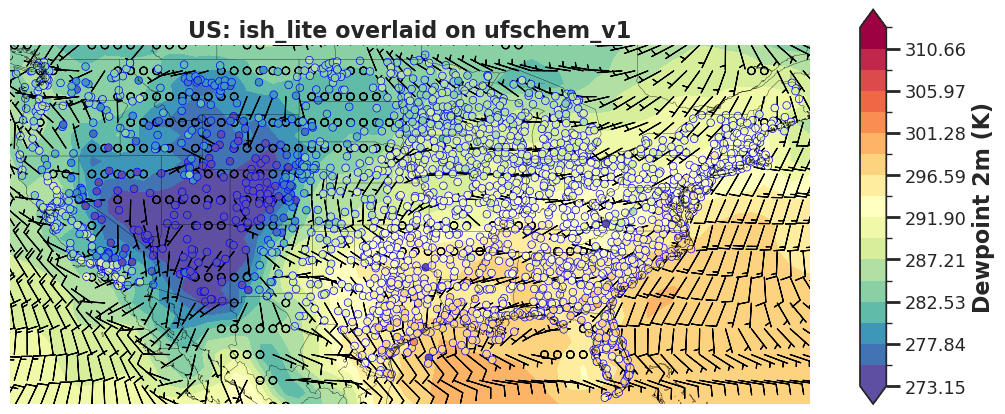

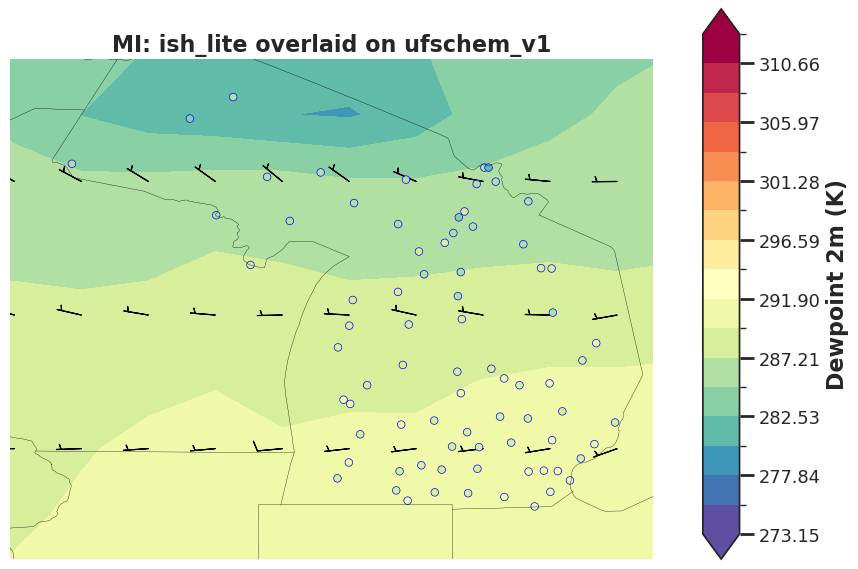

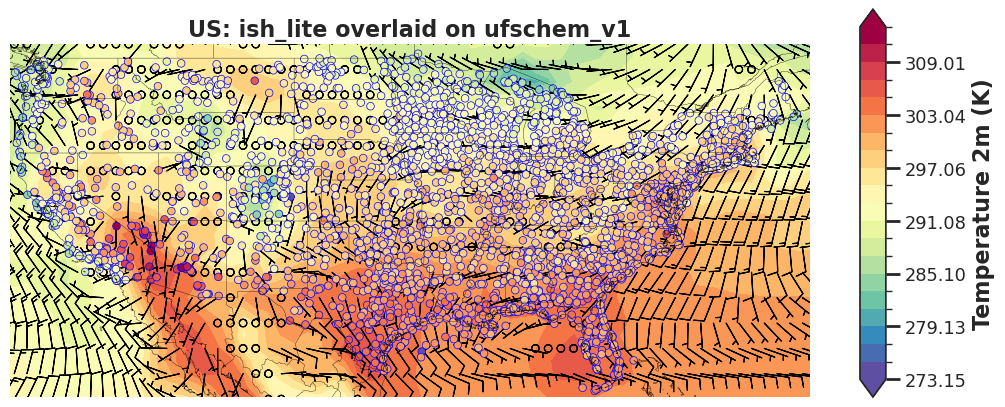

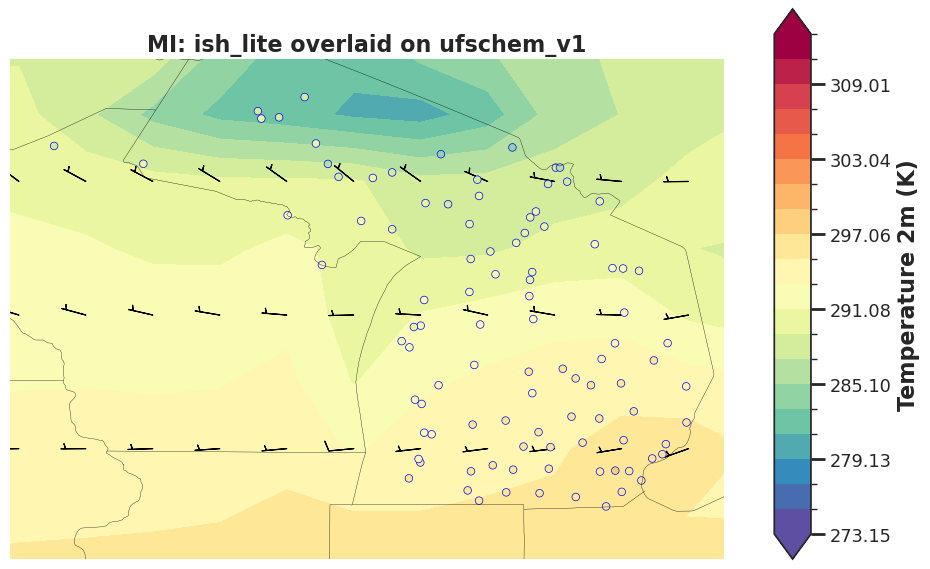

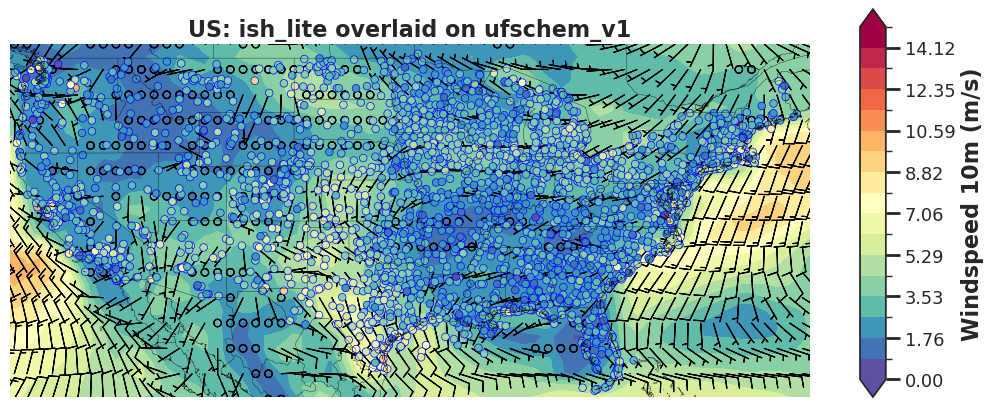

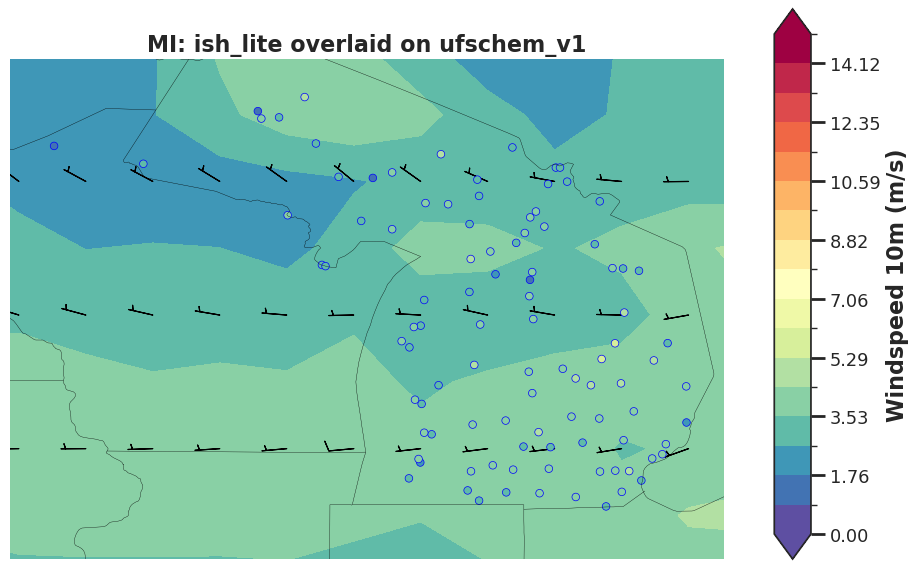

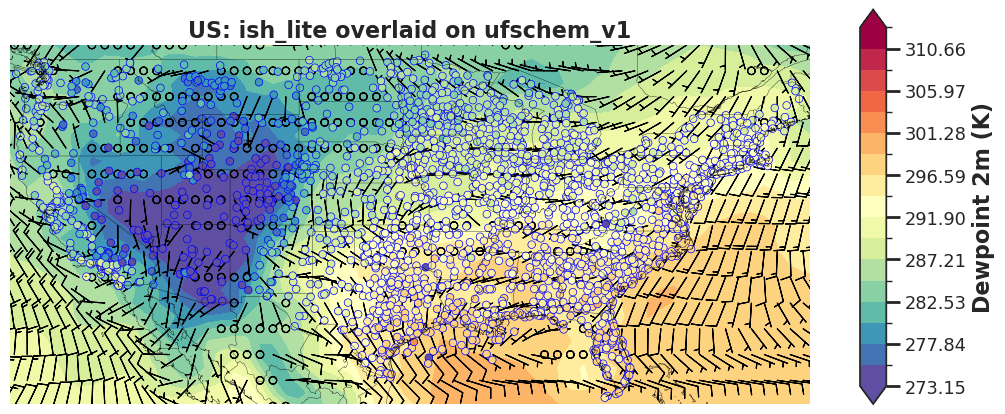

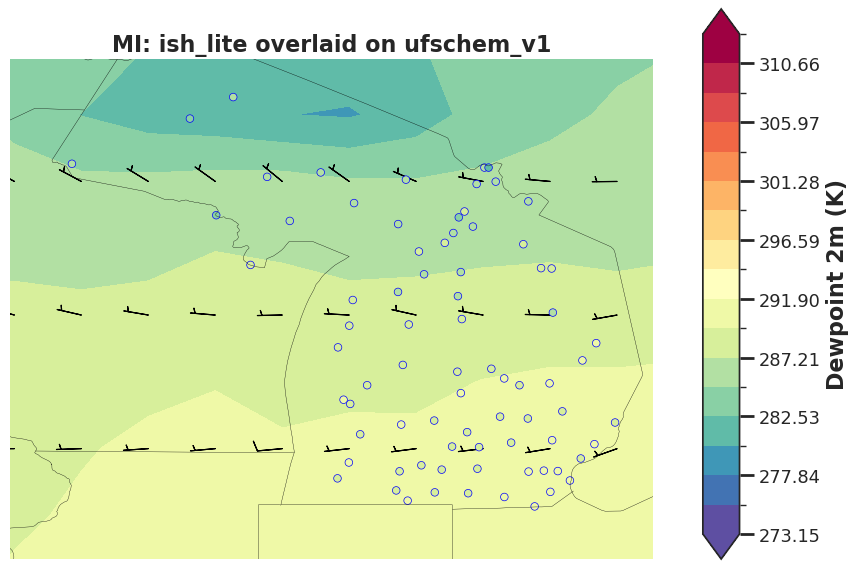

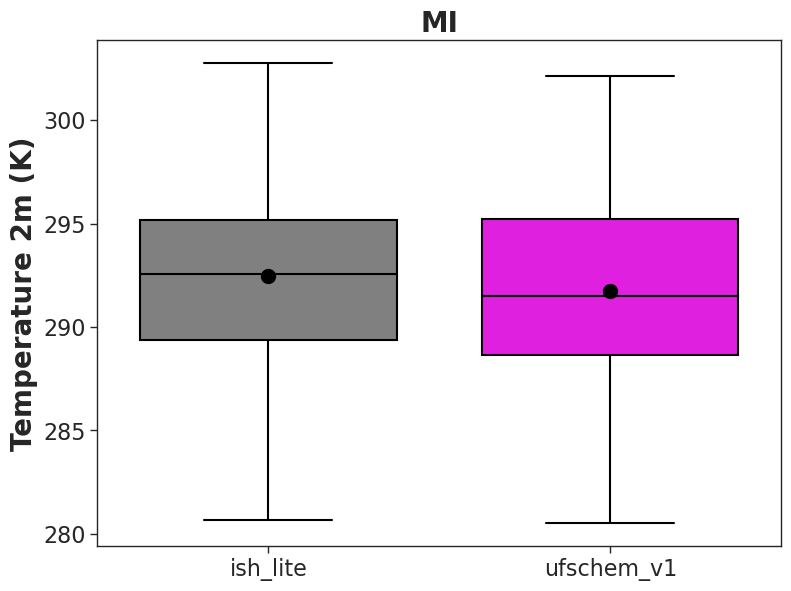

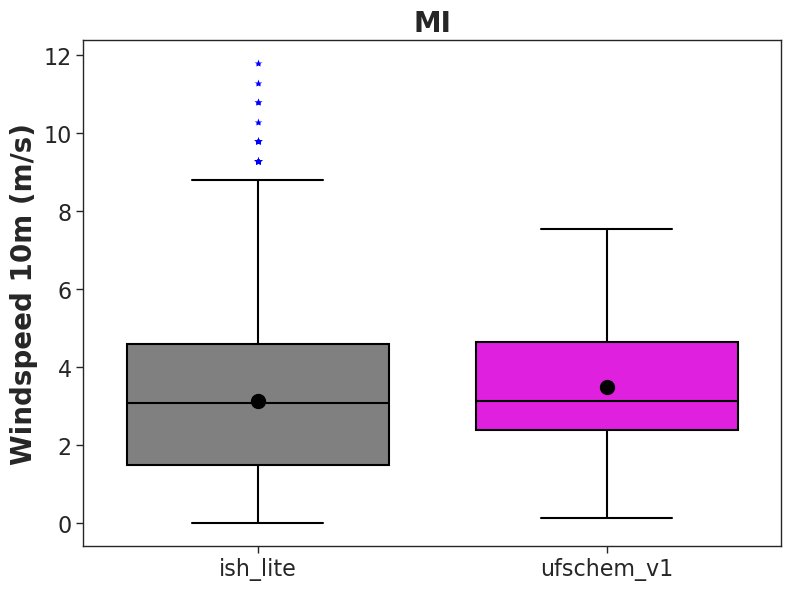

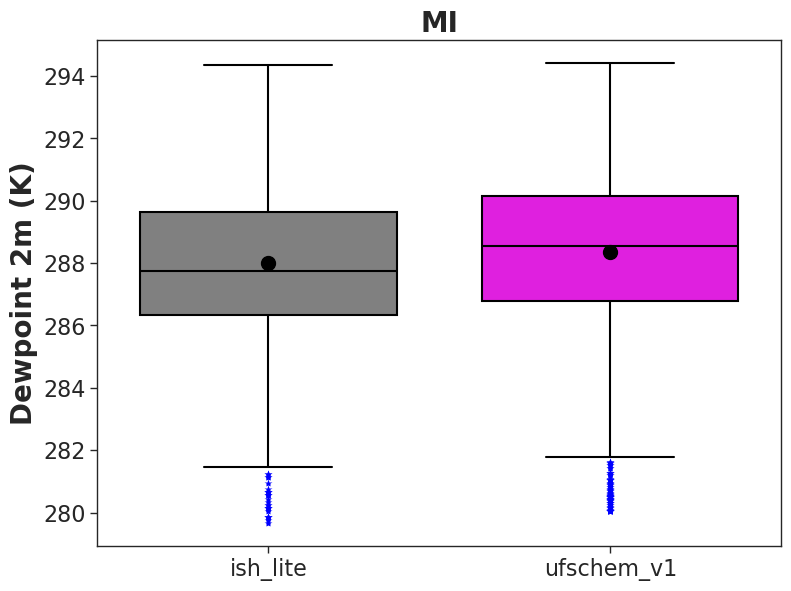

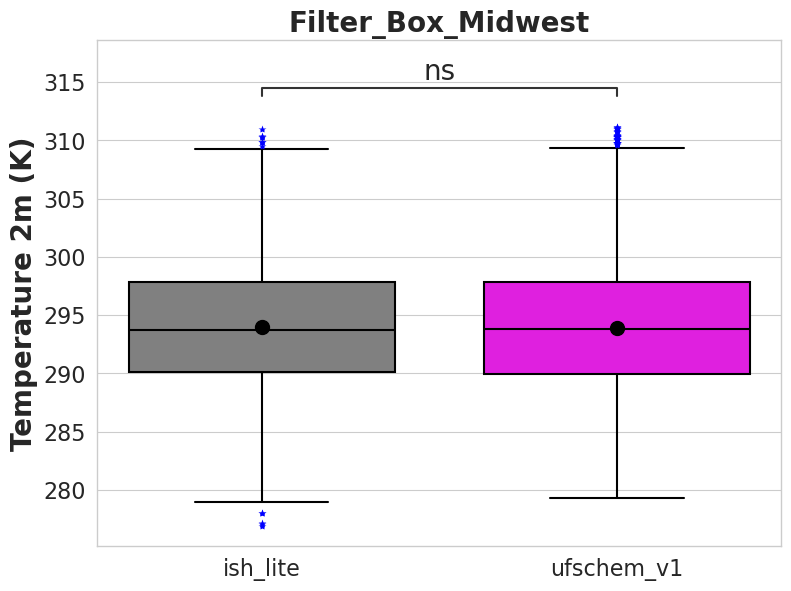

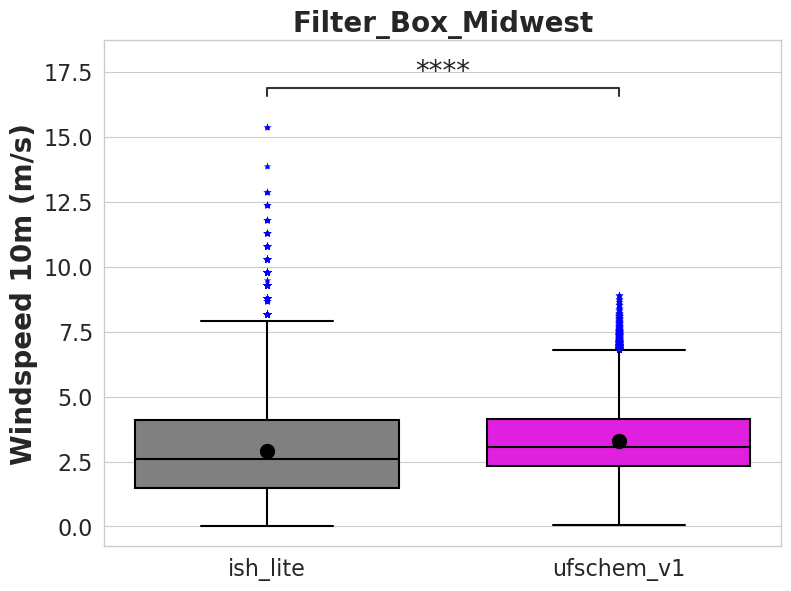

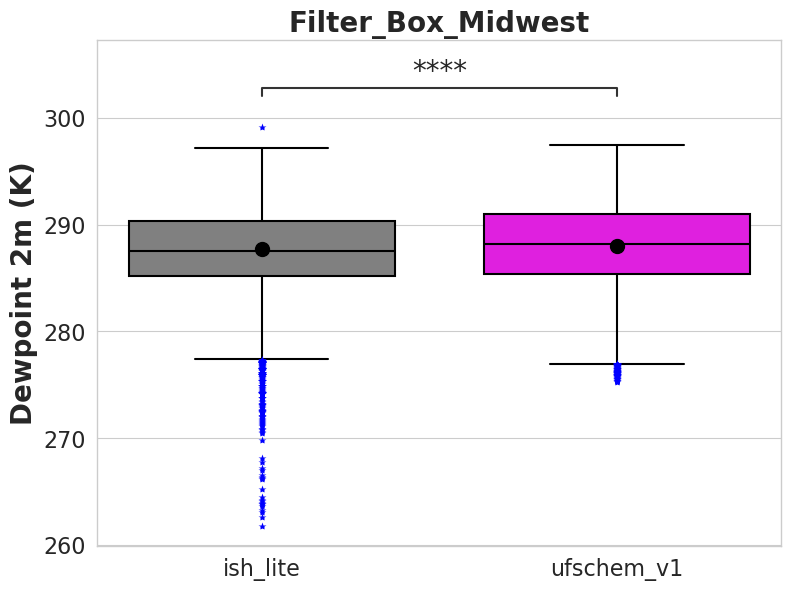

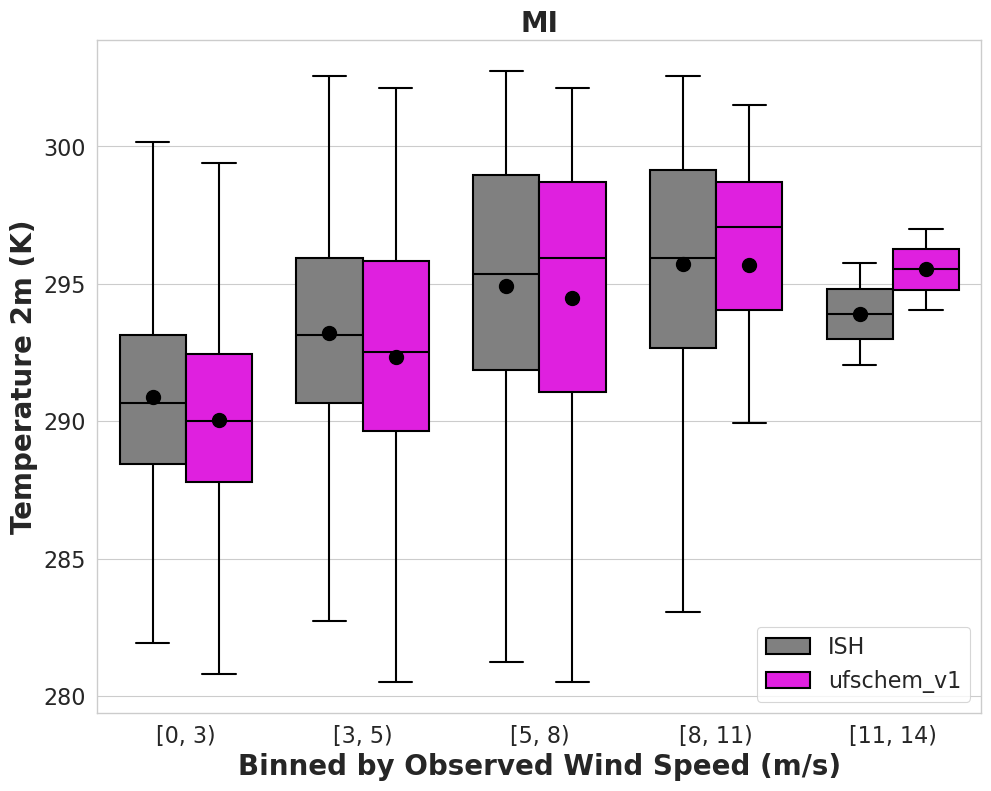

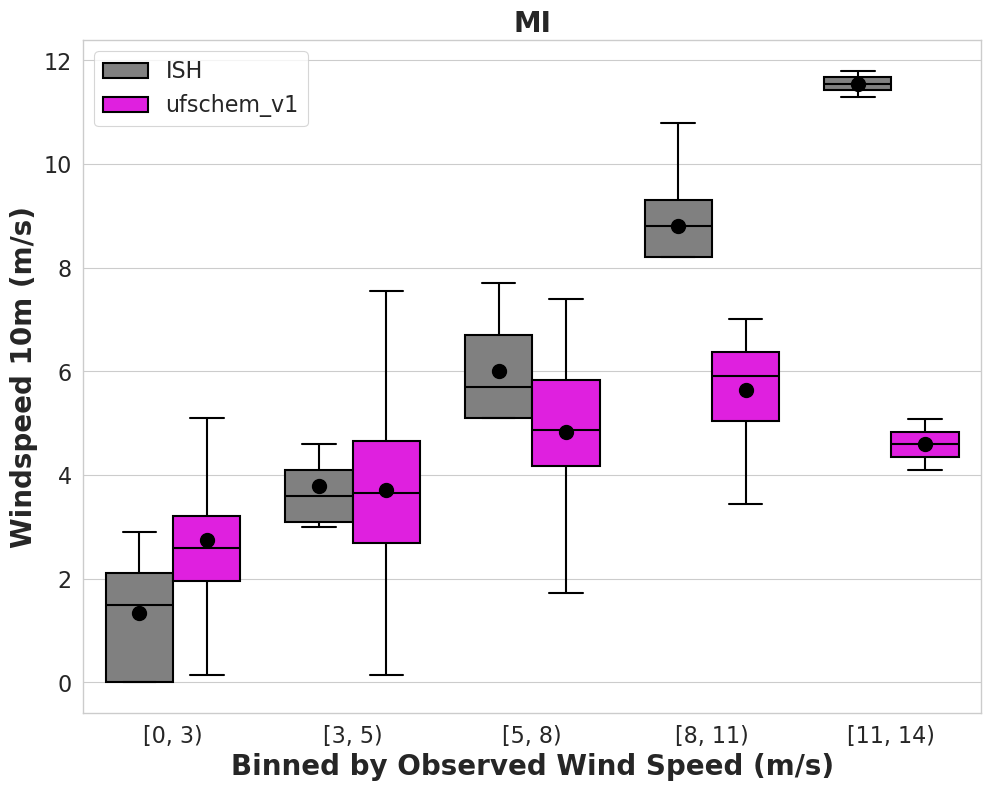

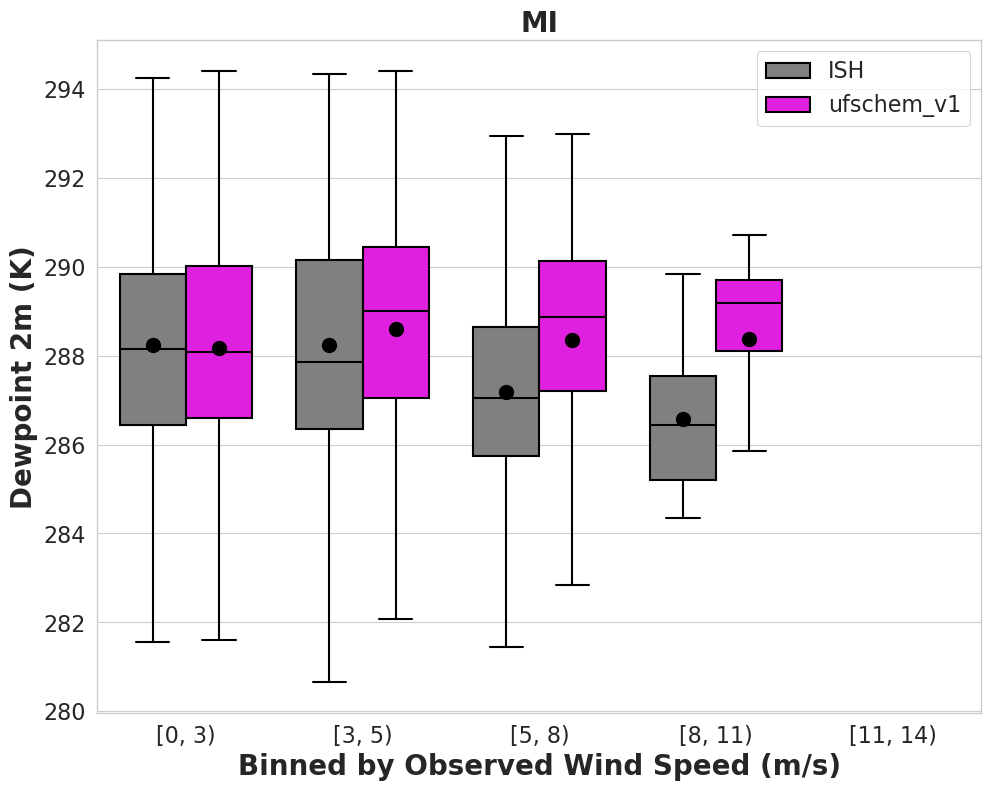

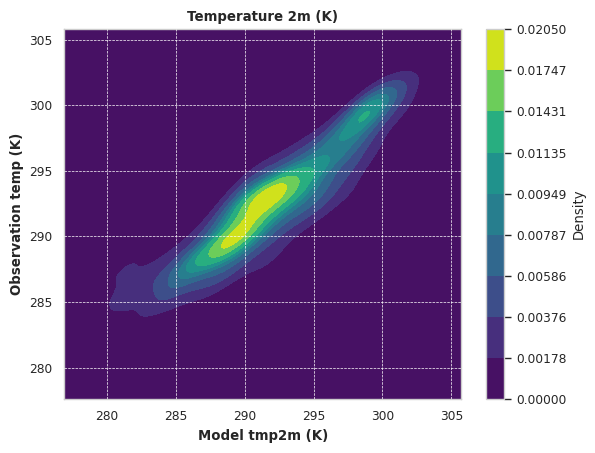

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/ish_lite_ufschem/plot_grp6.scatter_density.ws.2017-07-01_00.2017-07-03_00.state.MI_ish_lite_vs_ufschem_v1.png...
Processing scatter density plot for model 'ufschem_v1' and observation 'ish_lite'...
Saving scatter density plot to ./output/ish_lite_ufschem/plot_grp6.scatter_density.ws.2017-07-01_00.2017-07-03_00.state.MI_ish_lite_vs_ufschem_v1.png...


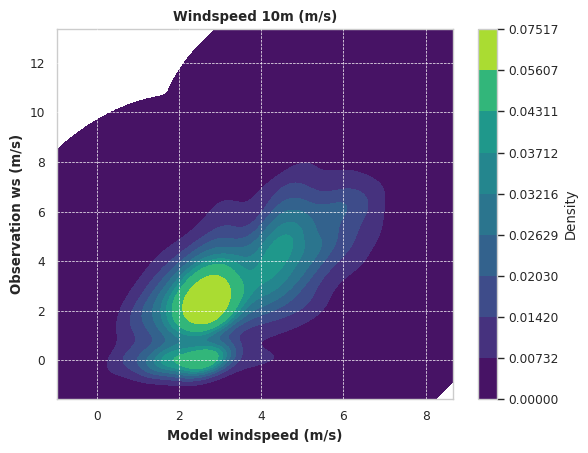

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/ish_lite_ufschem/plot_grp6.scatter_density.dew_pt_temp.2017-07-01_00.2017-07-03_00.state.MI_ish_lite_vs_ufschem_v1.png...
Processing scatter density plot for model 'ufschem_v1' and observation 'ish_lite'...
Saving scatter density plot to ./output/ish_lite_ufschem/plot_grp6.scatter_density.dew_pt_temp.2017-07-01_00.2017-07-03_00.state.MI_ish_lite_vs_ufschem_v1.png...


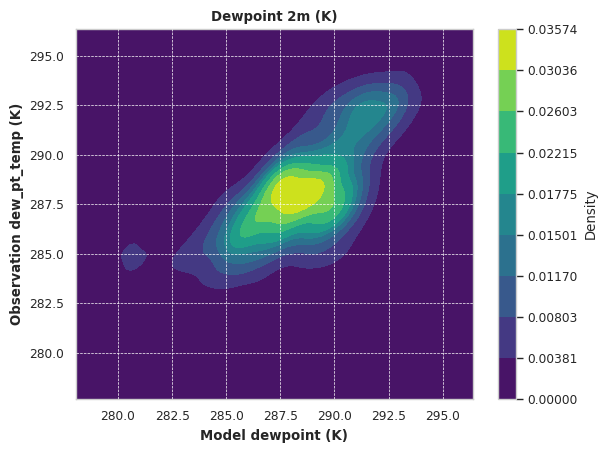

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.temp.2017-07-01_00.2017-07-03_00.state.MI...


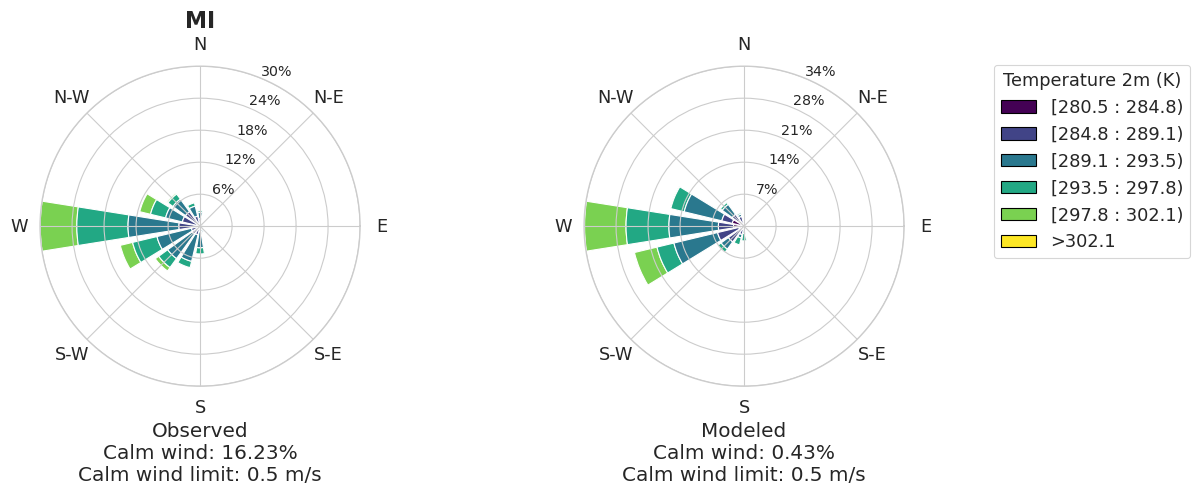

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.temp.2017-07-01_00.2017-07-03_00.siteid.72539614815...


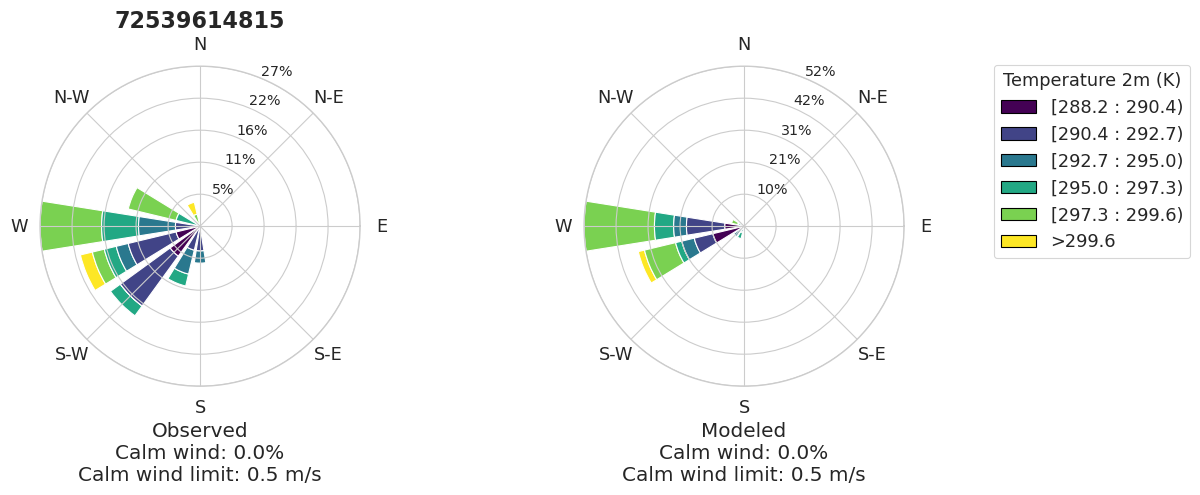

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.ws.2017-07-01_00.2017-07-03_00.state.MI...


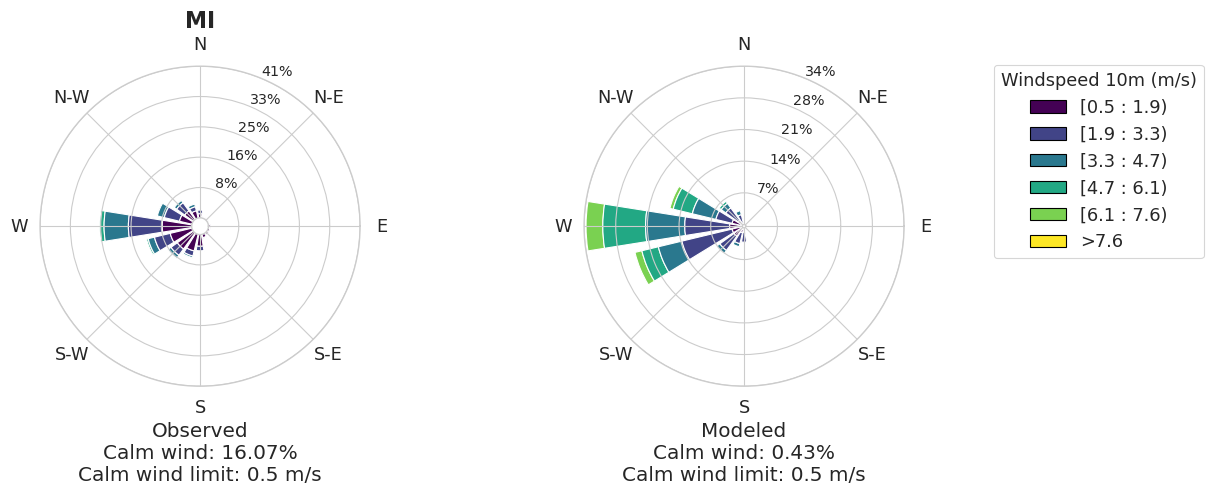

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.ws.2017-07-01_00.2017-07-03_00.siteid.72539614815...


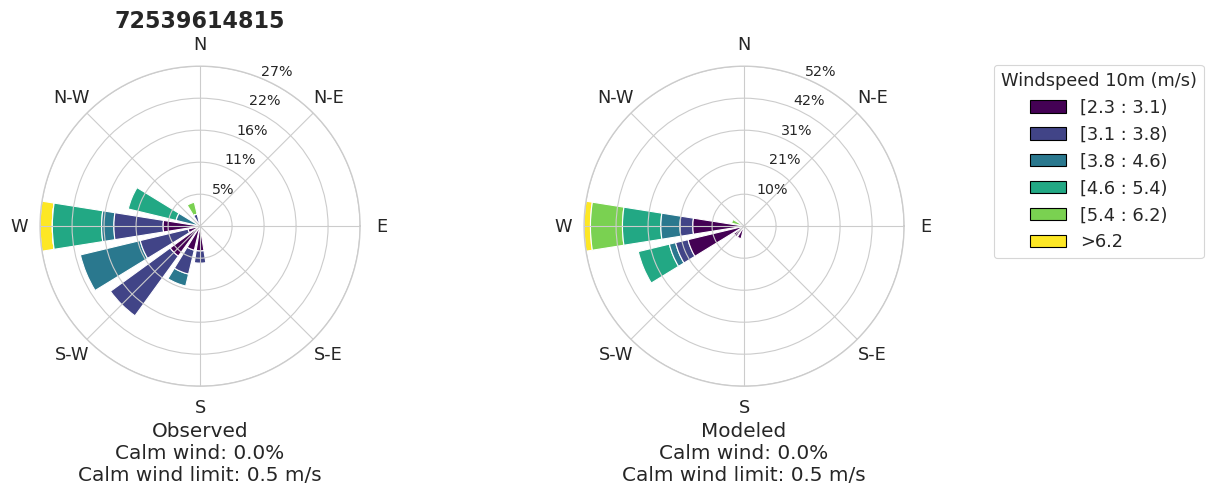

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.dew_pt_temp.2017-07-01_00.2017-07-03_00.state.MI...


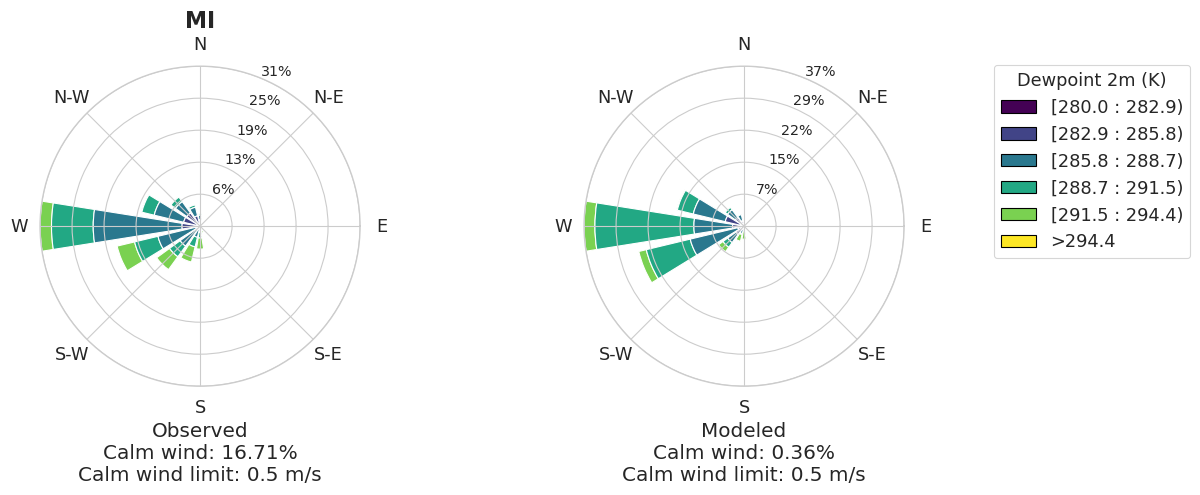

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.dew_pt_temp.2017-07-01_00.2017-07-03_00.siteid.72539614815...


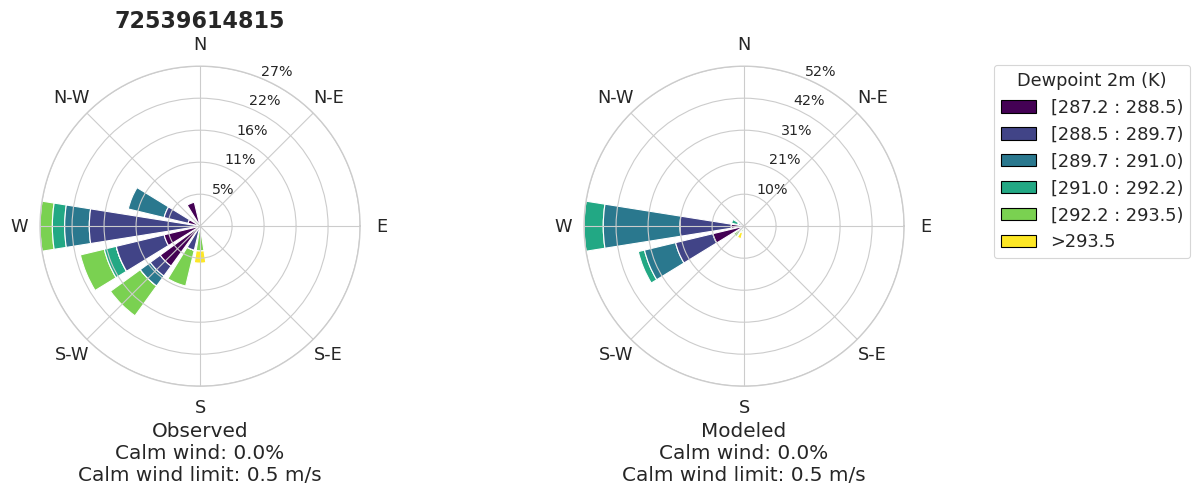

CPU times: user 3min 2s, sys: 6.4 s, total: 3min 9s
Wall time: 2min 22s


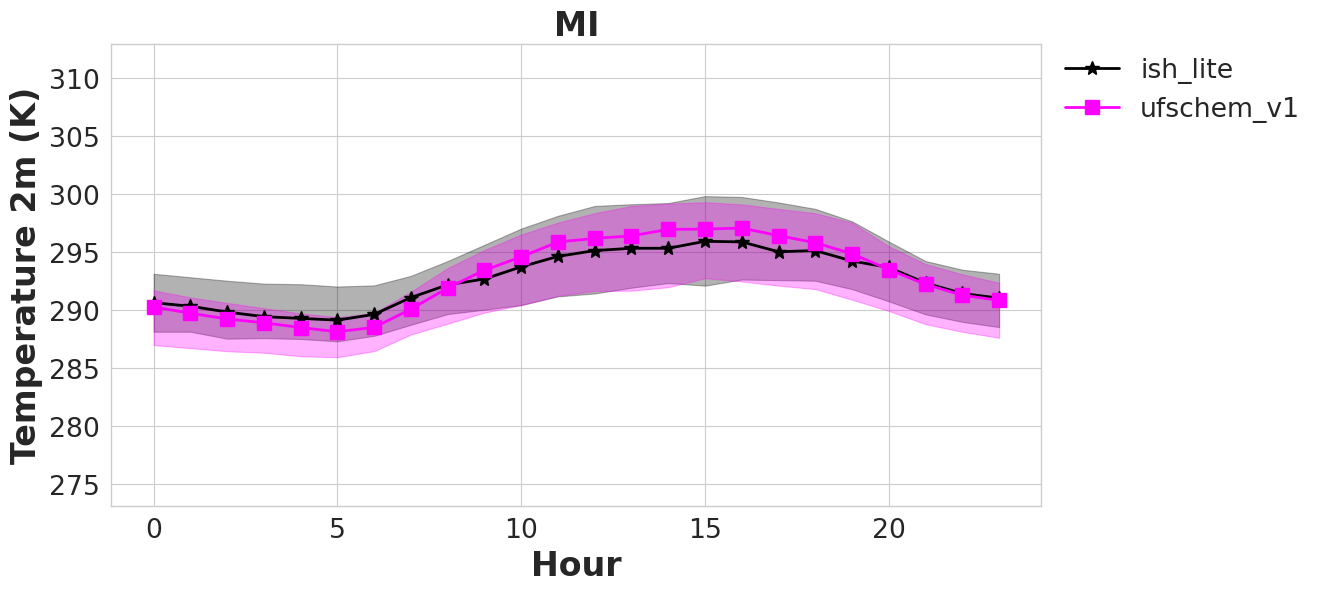

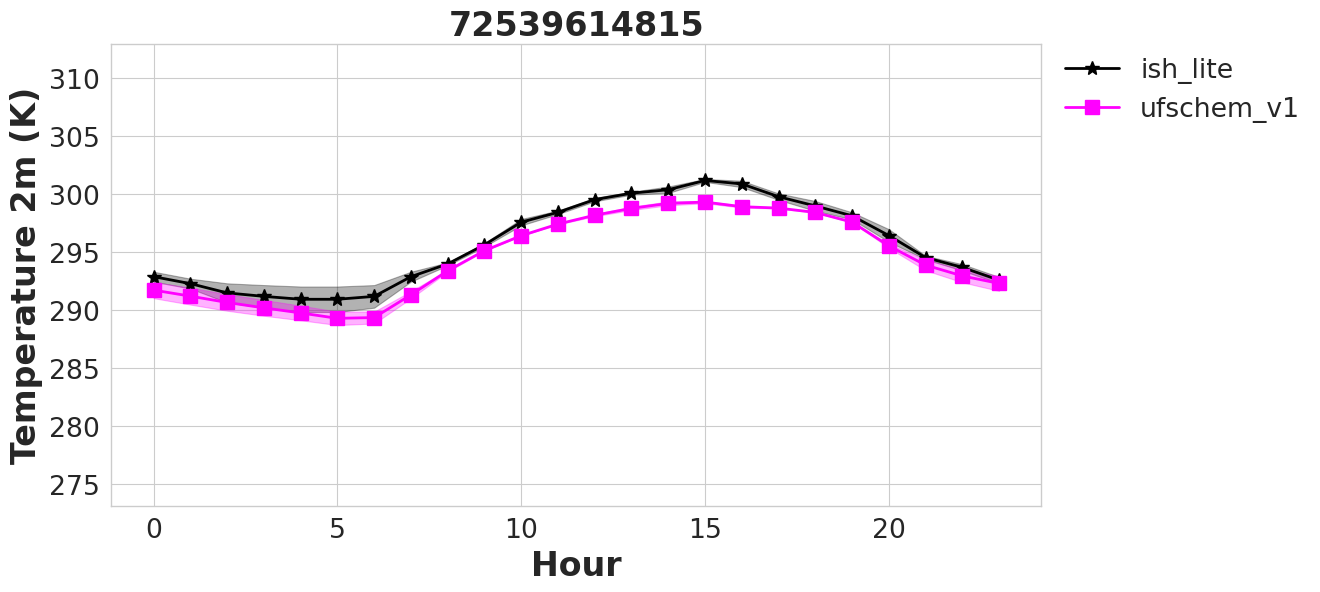

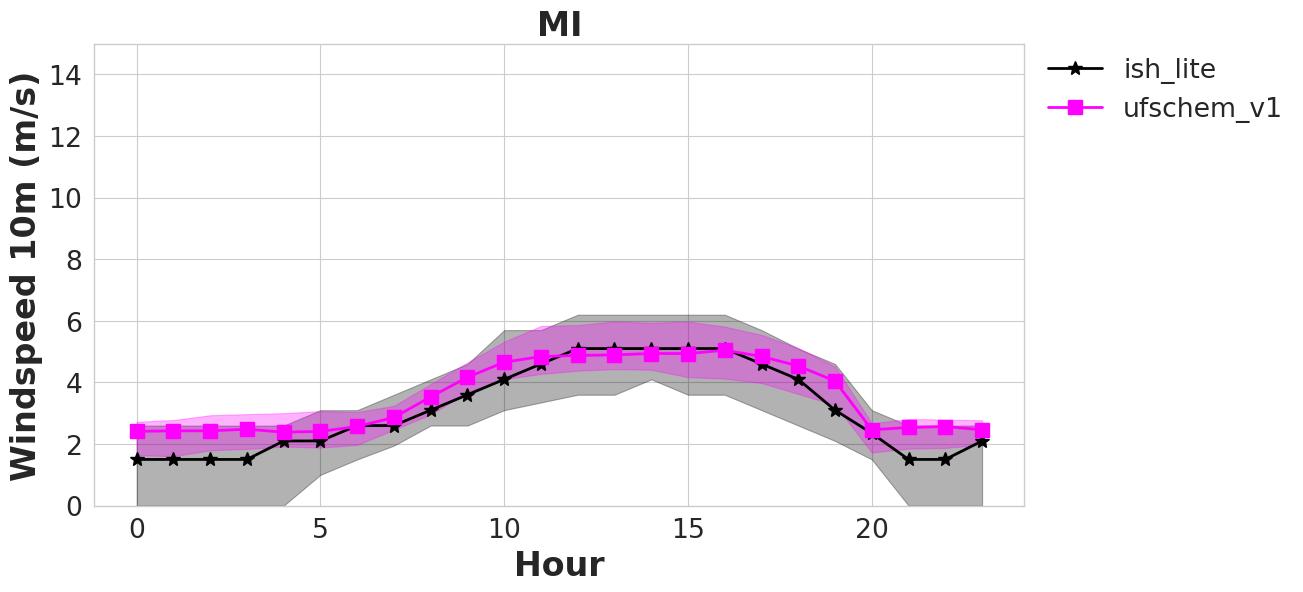

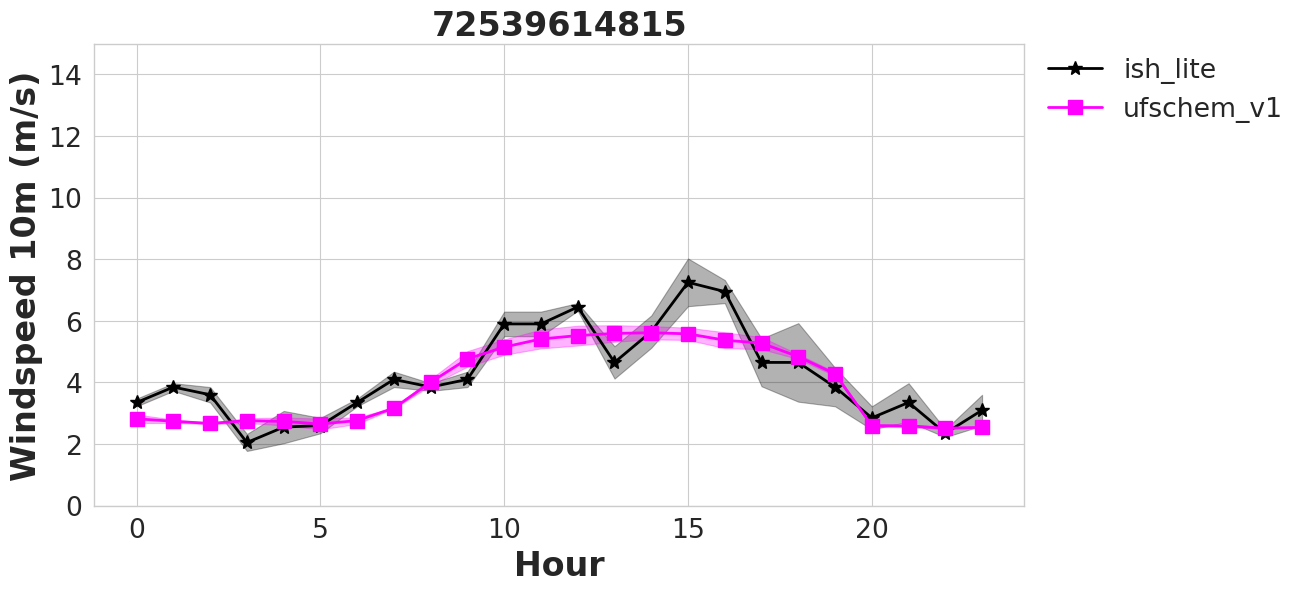

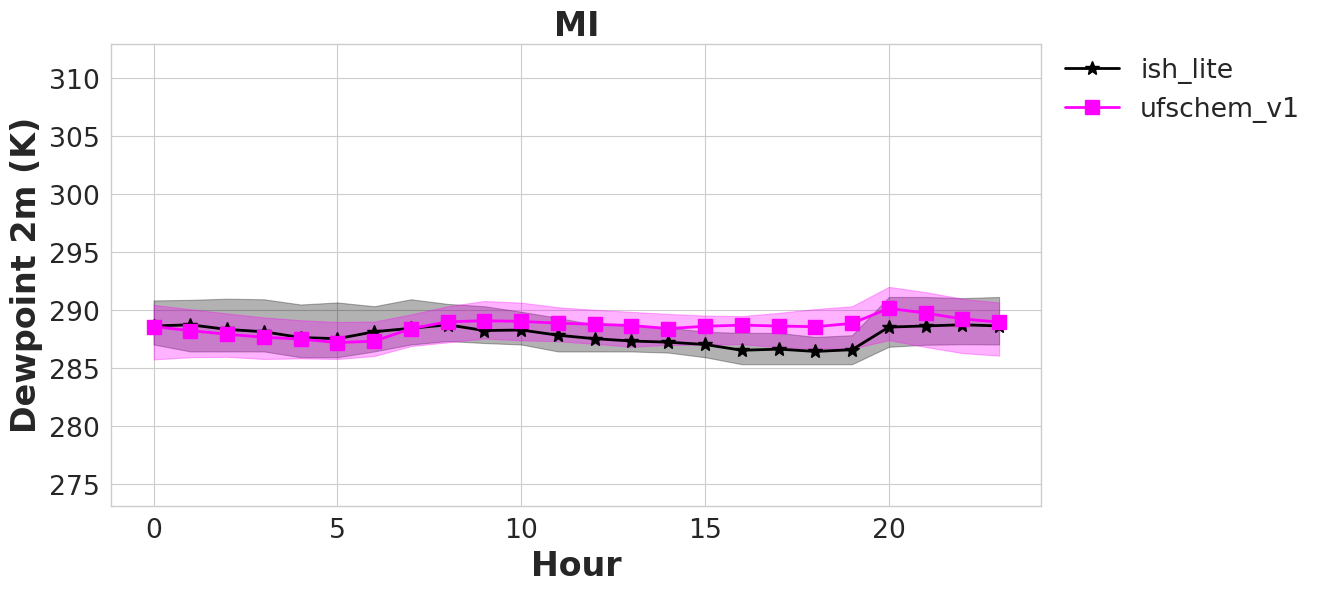

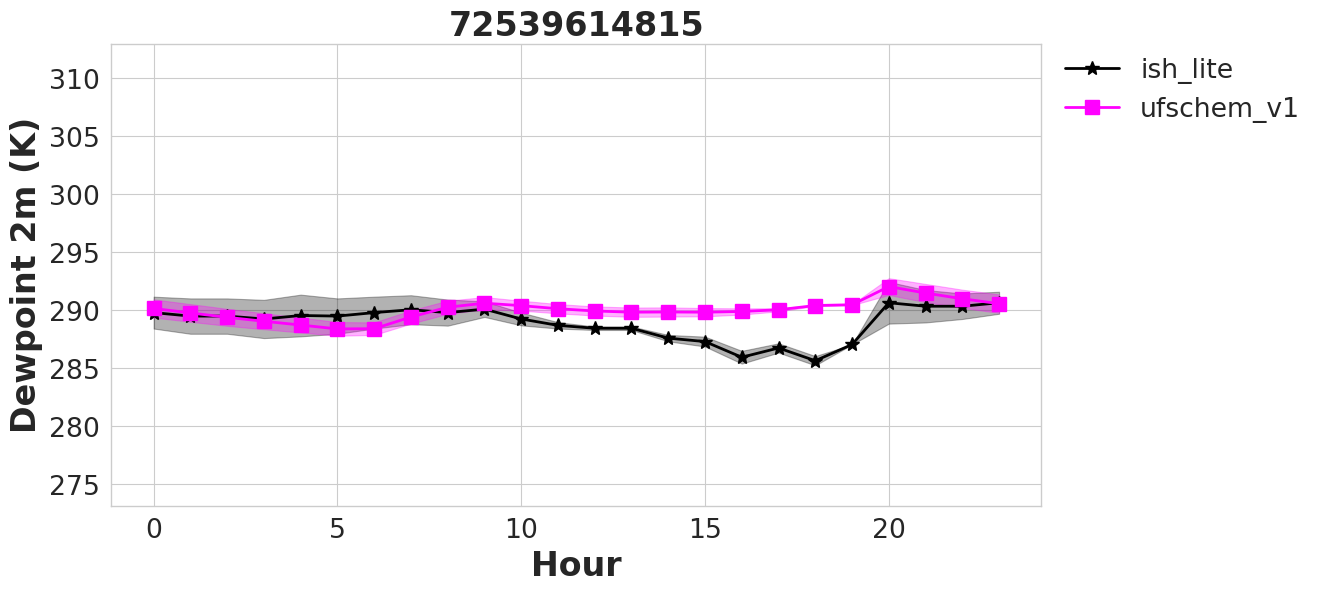

In [15]:
%%time

an.plotting()

CPU times: user 6.1 s, sys: 627 ms, total: 6.72 s
Wall time: 6.77 s


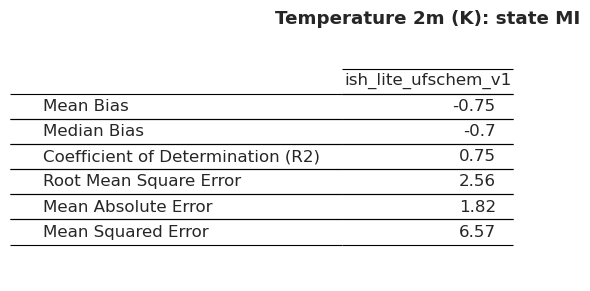

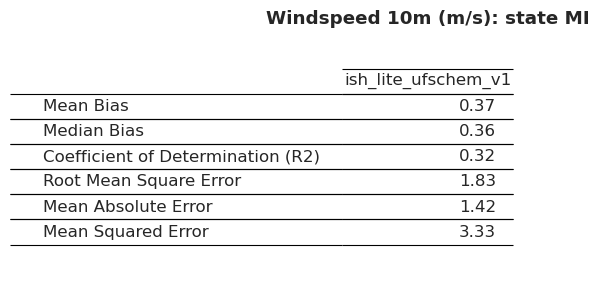

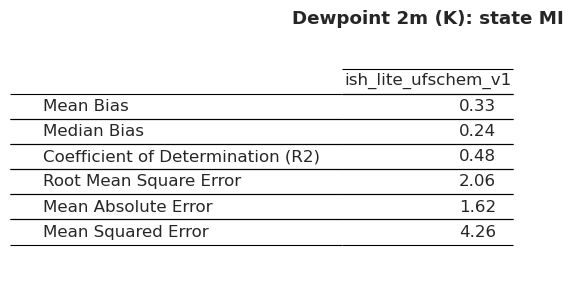

In [16]:
%%time

an.stats()

The stats routine has produced two files (one for each data variable).
This is one of them:
```{literalinclude} output/airnow_wrfchem/stats.OZONE.all.CONUS.2019-09-05_06.2019-09-06_06.csv
:caption:
```